# 1. Environment Setup & Data Loading

This section initializes the analytical environment, configures matplotlib parameters for publication-quality figures, and loads the `derived_8.2` soil moisture dataset splits (`train.csv`, `val.csv`, `test.csv`).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure current script dir and metadata paths are in sys.path
nb_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

split_metadata_dir = os.path.abspath(os.path.join(nb_dir, '..', '..', '..', 'data', 'splits', 'derived_8.2'))
if split_metadata_dir not in sys.path:
    sys.path.append(split_metadata_dir)

from dataset_metadata import TERNARY_REGIME_DRY_THRESHOLD, TERNARY_REGIME_WET_THRESHOLD, BINARY_REGIME_THRESHOLD

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

print("Loading derived_8.2 dataset splits...")
split_dir = os.path.abspath(os.path.join(nb_dir, '..', '..', '..', 'data', 'splits', 'derived_8.2'))
train_df = pd.read_csv(os.path.join(split_dir, 'train.csv'))
val_df = pd.read_csv(os.path.join(split_dir, 'val.csv'))
test_df = pd.read_csv(os.path.join(split_dir, 'test.csv'))

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)
df_all['date'] = pd.to_datetime(df_all['date'])
df_all['year'] = df_all['date'].dt.year

print(f"Loaded {len(df_all)} total rows across {df_all['station_id'].nunique()} stations.")

Loading derived_8.2 dataset splits...


Loaded 31755 total rows across 12 stations.


C:\Users\pan\AppData\Local\Temp\ipykernel_25068\2517562936.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['split'] = 'train'
C:\Users\pan\AppData\Local\Temp\ipykernel_25068\2517562936.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_df['split'] = 'val'
C:\Users\pan\AppData\Local\Temp\ipykernel_25068\2517562936.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

# 2. Station Data Entry Counts by Year & Missingness Analysis

In this section, we examine the data entry counts (observations per year) for each station in `derived_8.2` across 2017–2025. This identifies stations with severe missing data (e.g. missing full years or sparse data records).

Loading derived_8.2 data splits for station data entry count analysis...



=== Data Entry Counts by Station and Year ===
year                   2017  2018  2019  2020  2021  2022  2023  2024  2025
station_id                                                                 
BeaverPass_WA_990       365   364   365   365   361   365   365   225    36
BurntMountain_WA        332   194     0   221   258   232   190     7    49
CayusePass_WA           324   364   365   361   364   264   350   366   365
Darrington              340   350   324   363   335   336   317   350   332
HartsPass_WA_515         91   365   343   272   199   241    19    70     0
MartenRidge_WA_999      365   365   365   359   359   354   361   348    81
Paradise_WA             363   365   365   366   365   365   365   337   365
Quinault                353   364   364   366   351   362   323   361   360
RainyPass_WA_711        344   360   365   352   365   336   361   280   345
SourdoughGulch_WA_985   365   365   365   366   365   365   365   366   175
Spokane                 273   307   274  

C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-data-exploration\analyze_station_data_entry_counts.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#ffe6e6', edgecolor='white', lw=1))


Saved station data entry count visualizations successfully!


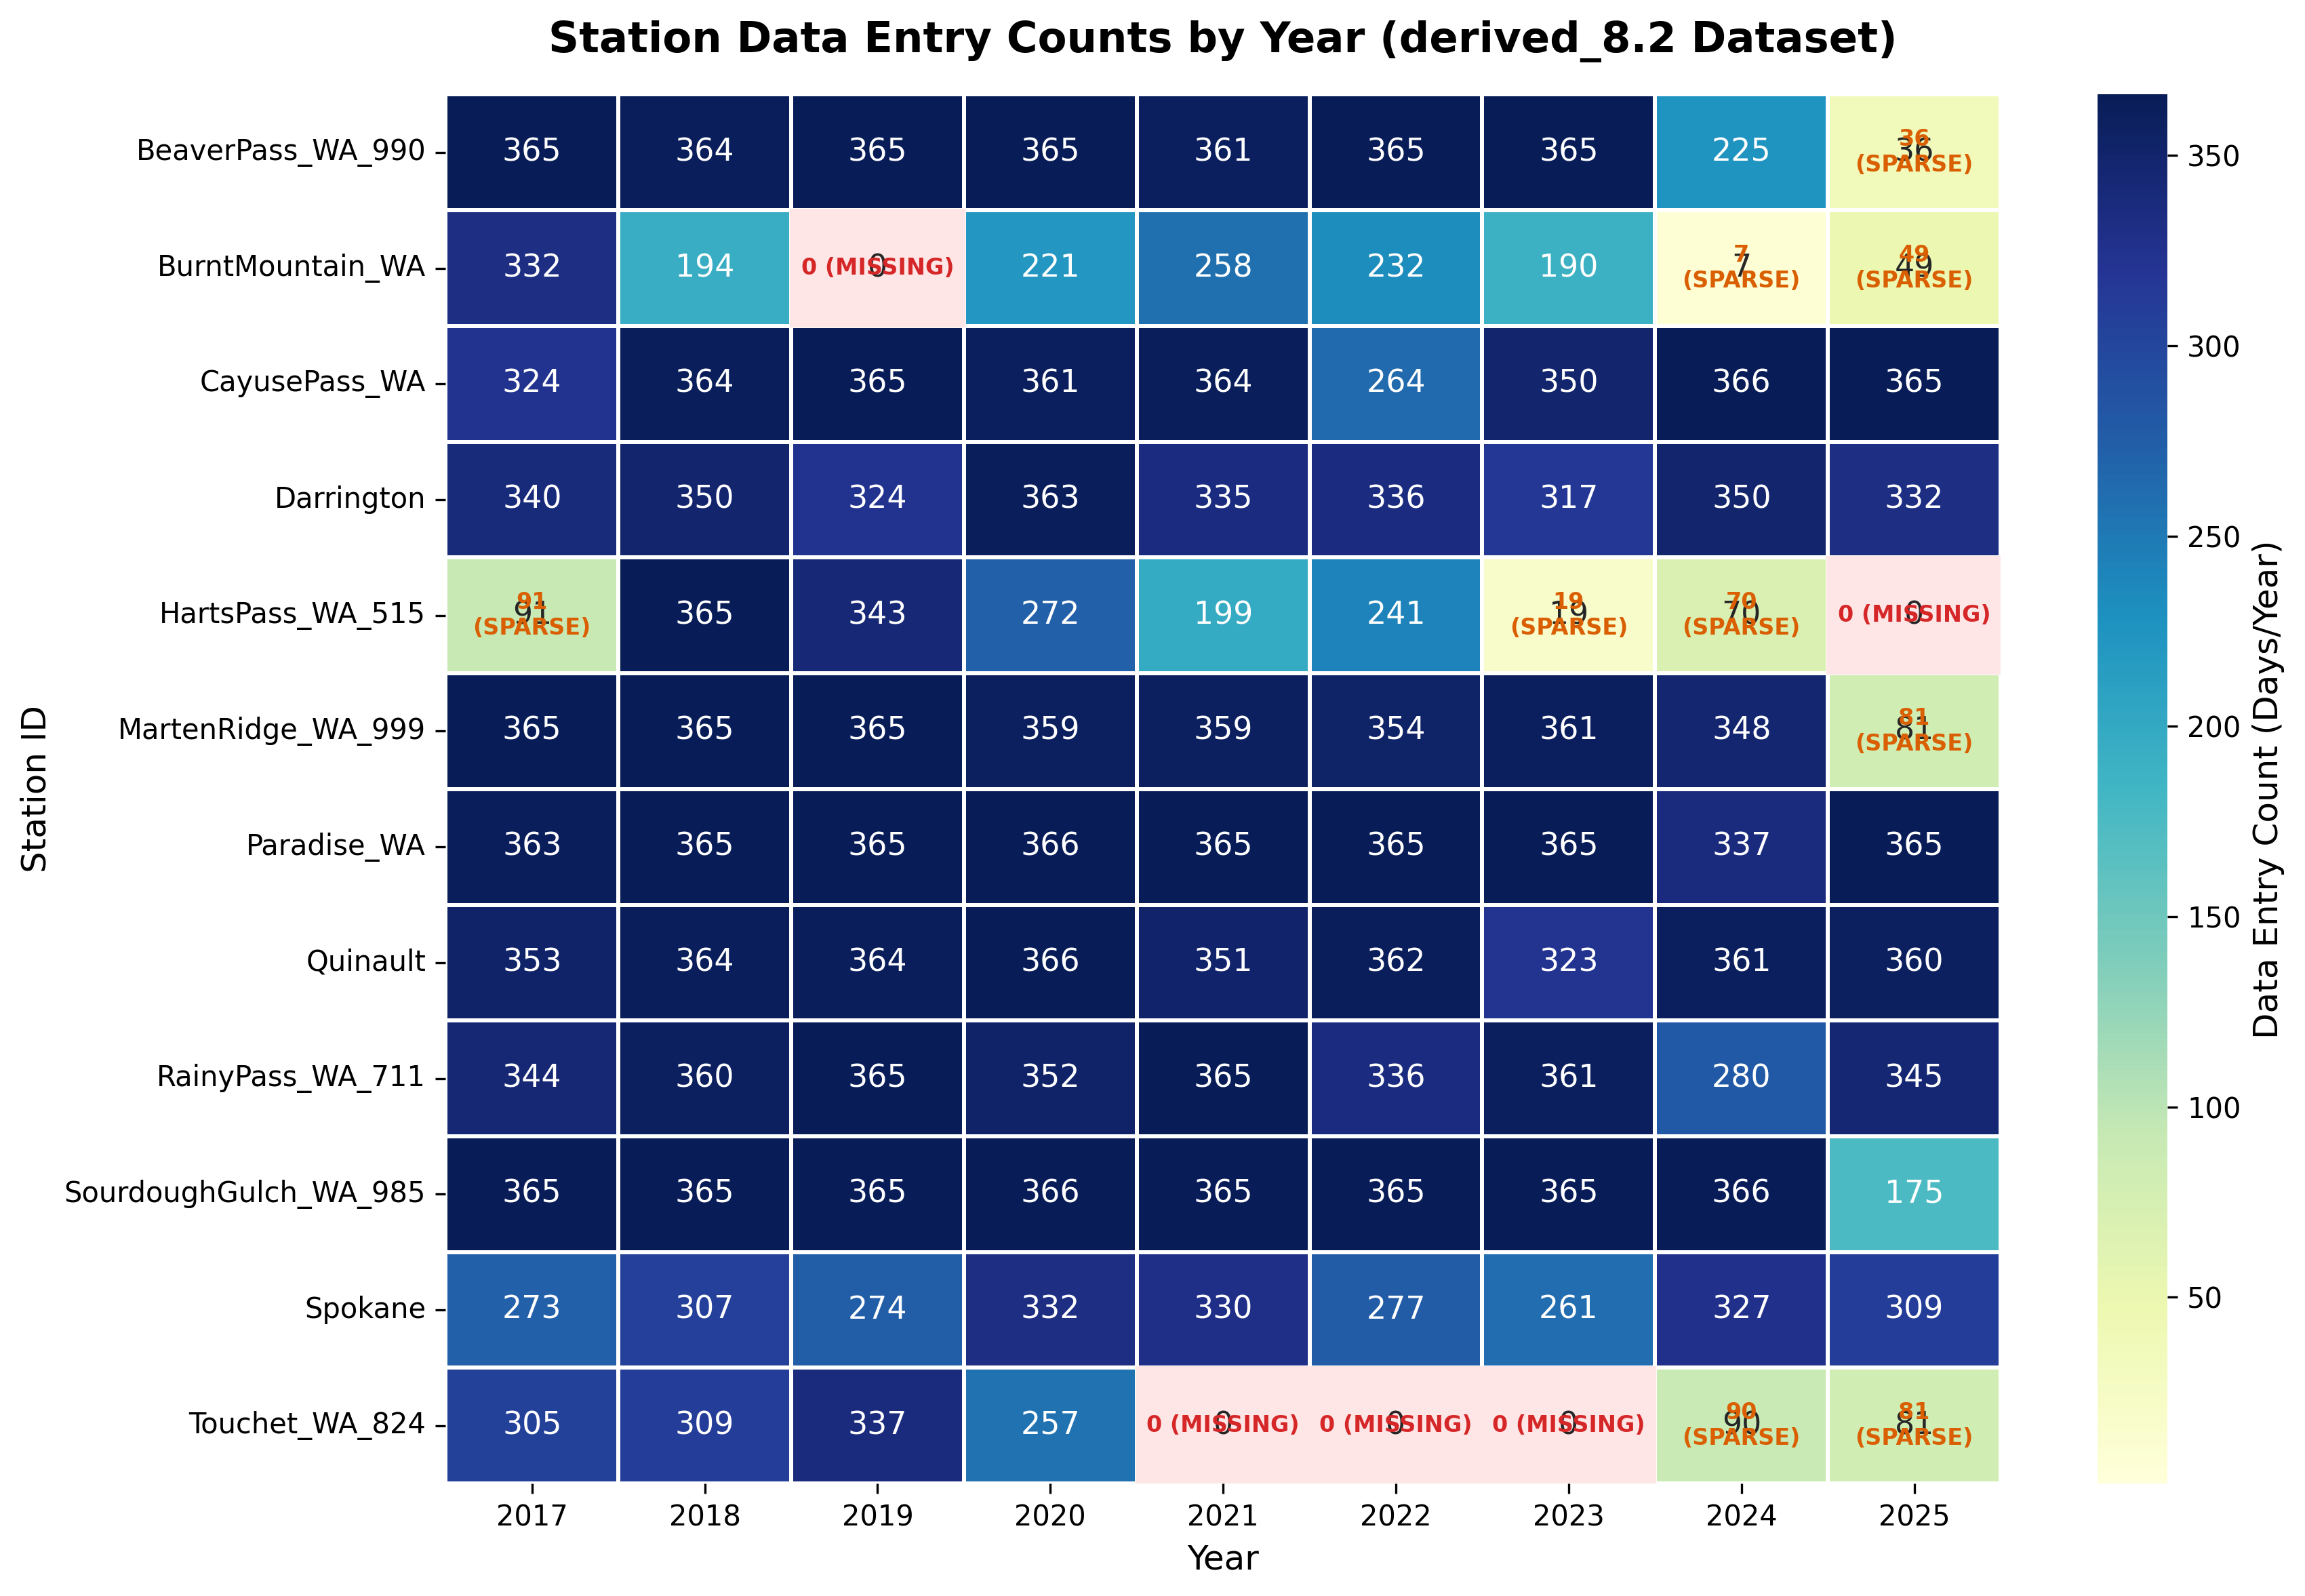

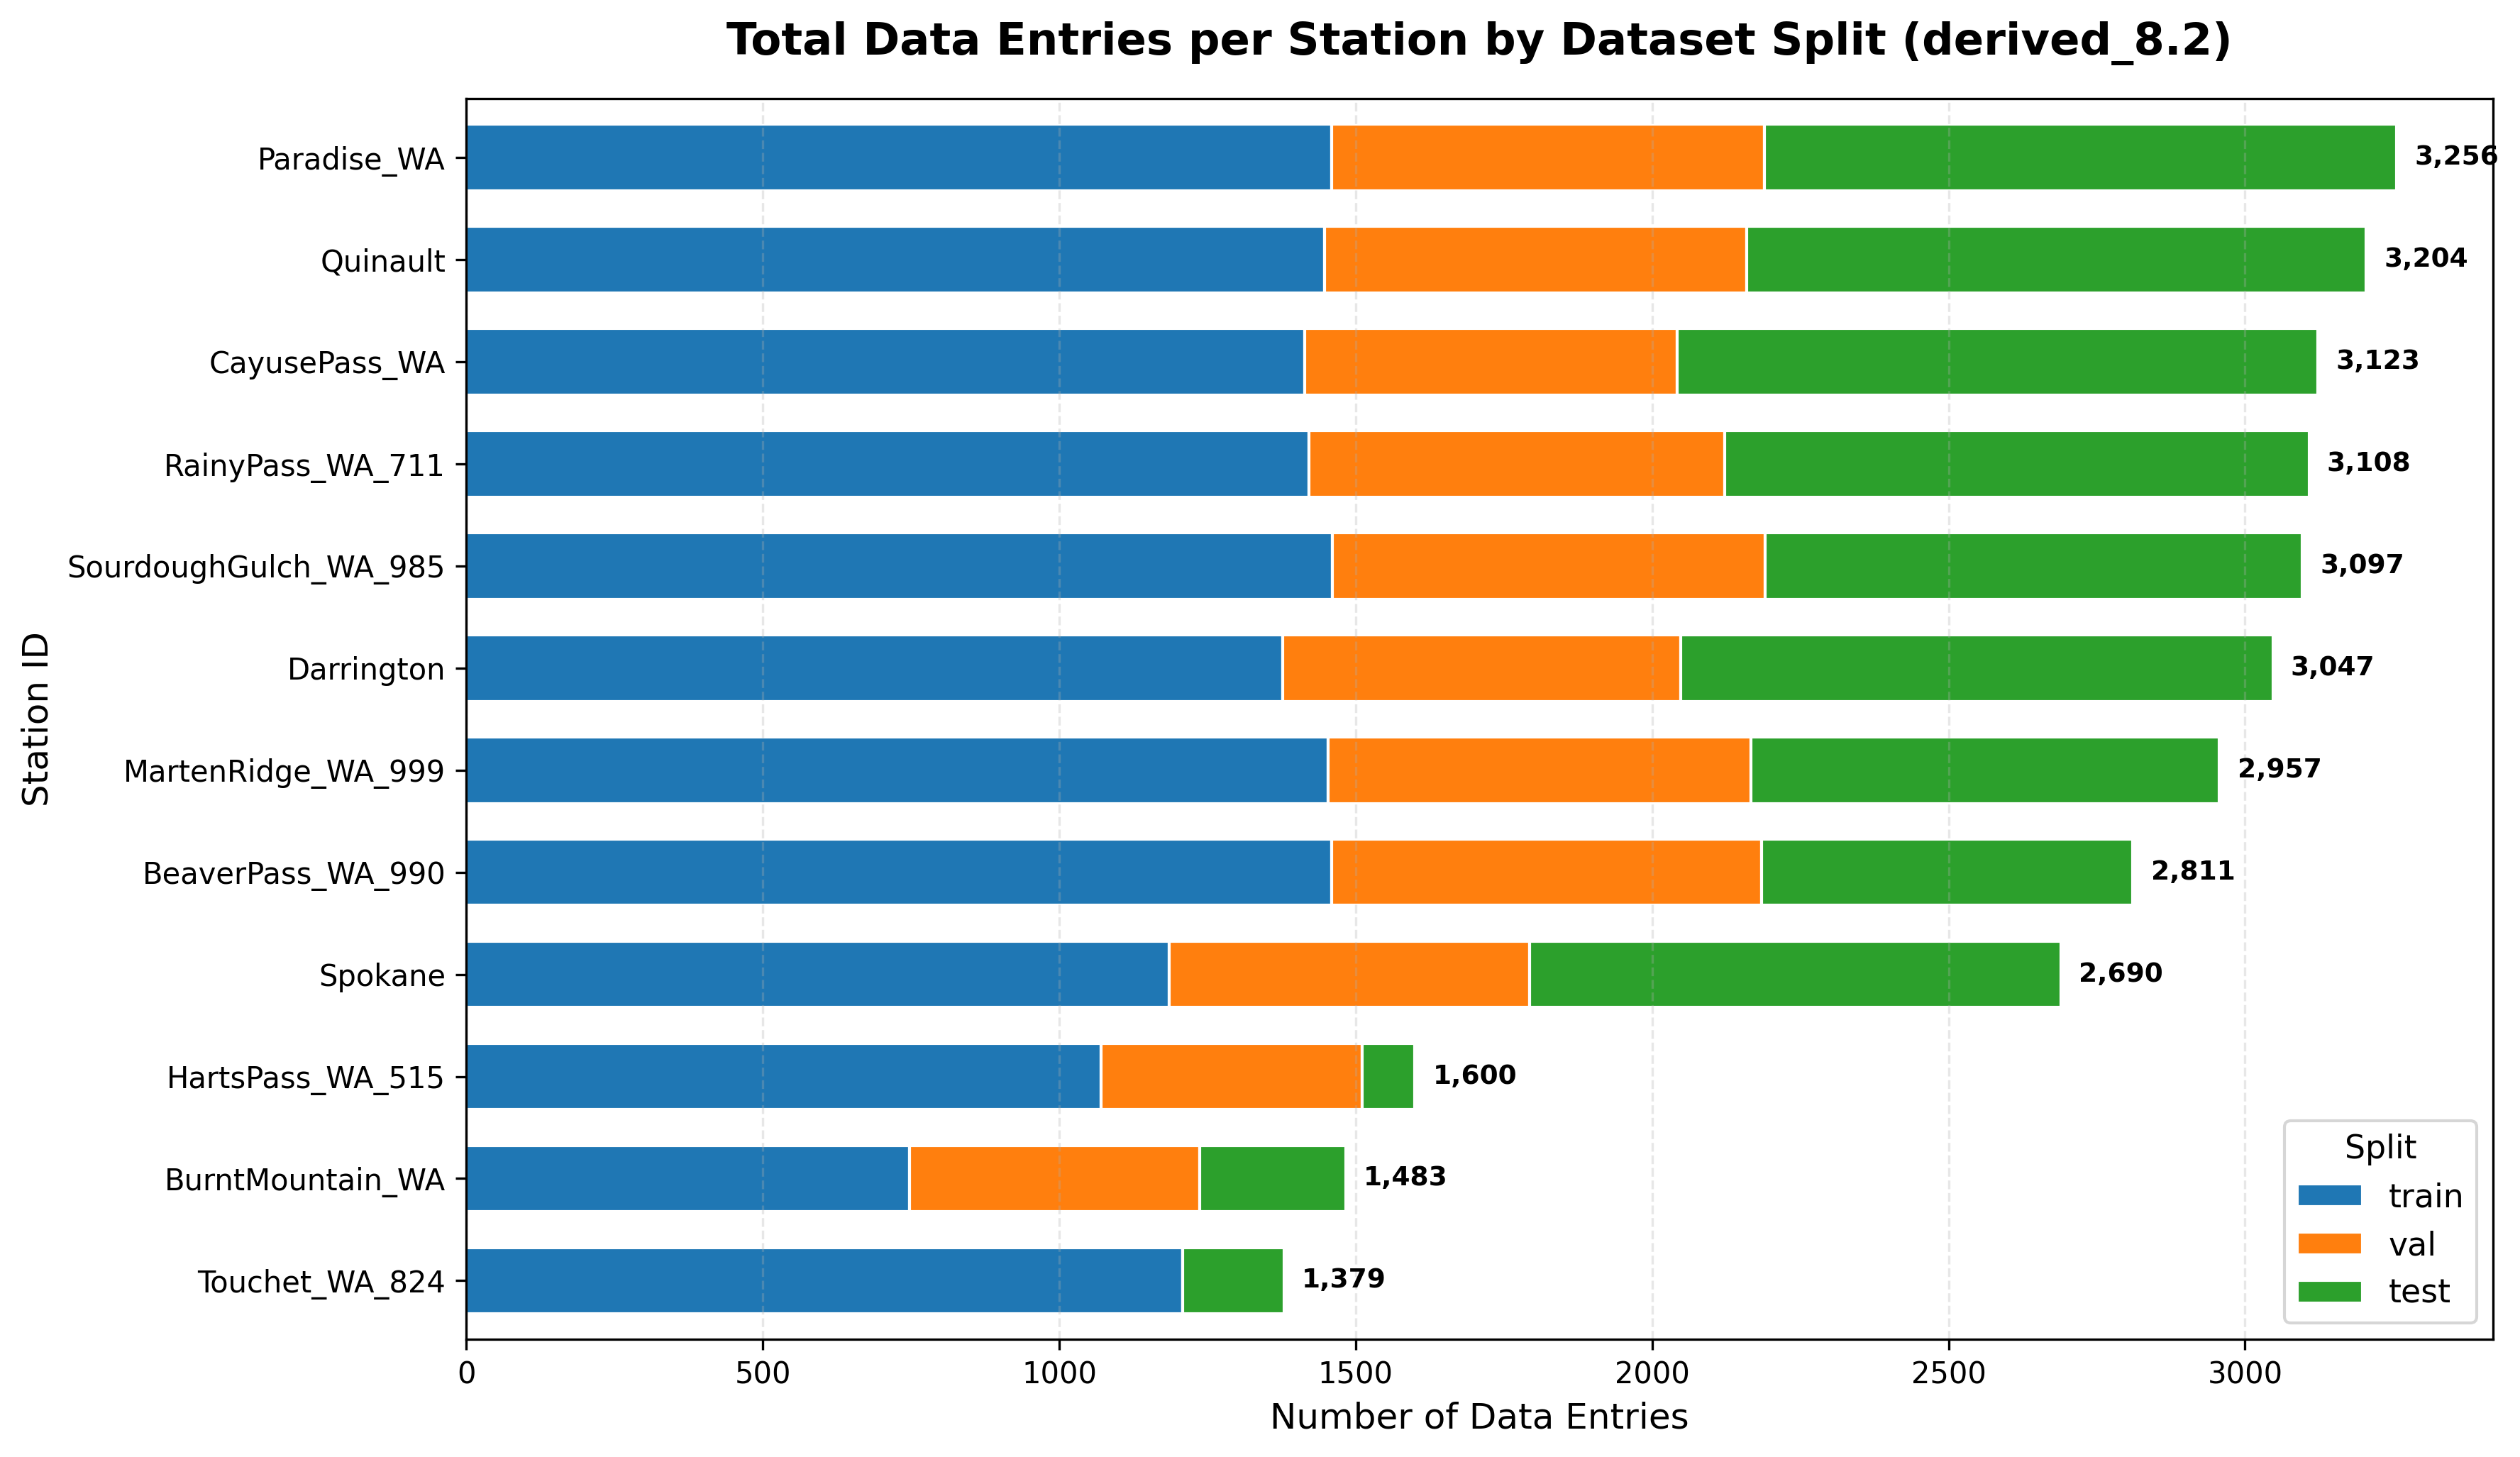

In [2]:
import analyze_station_data_entry_counts
analyze_station_data_entry_counts.main()

from IPython.display import Image, display
display(Image(os.path.join(nb_dir, 'station_data_entries_heatmap.png')))
display(Image(os.path.join(nb_dir, 'station_data_entries_by_year.png')))

# 3. Target Soil Moisture Distribution & Regime Calibration

Here we analyze the target distribution (`soil_moisture_5cm`), KDE mode/valley detection, and compare aggregated 3-regime ($t_1=0.16, t_2=0.25$) and 2-regime ($T=0.16$) split proportions against baseline `derived_8.0`.

Loading derived_8.2 training split for valley calibration...



=== KDE Peak and Valley Detection ===
Modes (Peaks) at SM values: [0.0288 0.1338 0.2005 0.3099]
Valleys (Minima) at SM values: [0.0613 0.159  0.2477]


Saved programmatic_valleys_calibration.png!
Loading derived_8.2 data splits...


Loading baseline derived_8.0 data split for density comparison...



=== Dataset Row and Station Counts ===
derived_8.2 Total rows: 31755 (Train: 15704, Val: 7149, Test: 8902)
derived_8.2 Stations (12): ['BeaverPass_WA_990', 'BurntMountain_WA', 'CayusePass_WA', 'Darrington', 'HartsPass_WA_515', 'MartenRidge_WA_999', 'Paradise_WA', 'Quinault', 'RainyPass_WA_711', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

=== Target (soil_moisture_5cm) Quantiles in Train Set ===
Percentile  derived_8.0 (Train)  derived_8.2 (Train)
        0%               0.0000                0.001
       10%               0.0390                0.047
       25%               0.1210                0.124
       33%               0.1570                0.151
       50%               0.2060                0.211
       66%               0.2530                0.270
       75%               0.2800                0.301
       90%               0.3203                0.349
      100%               0.4390                0.439

3-Regime Thresholds: Original (t1=0.2, t2=0.313), Valleys (

Successfully completed analyze_regimes.py for derived_8.2!


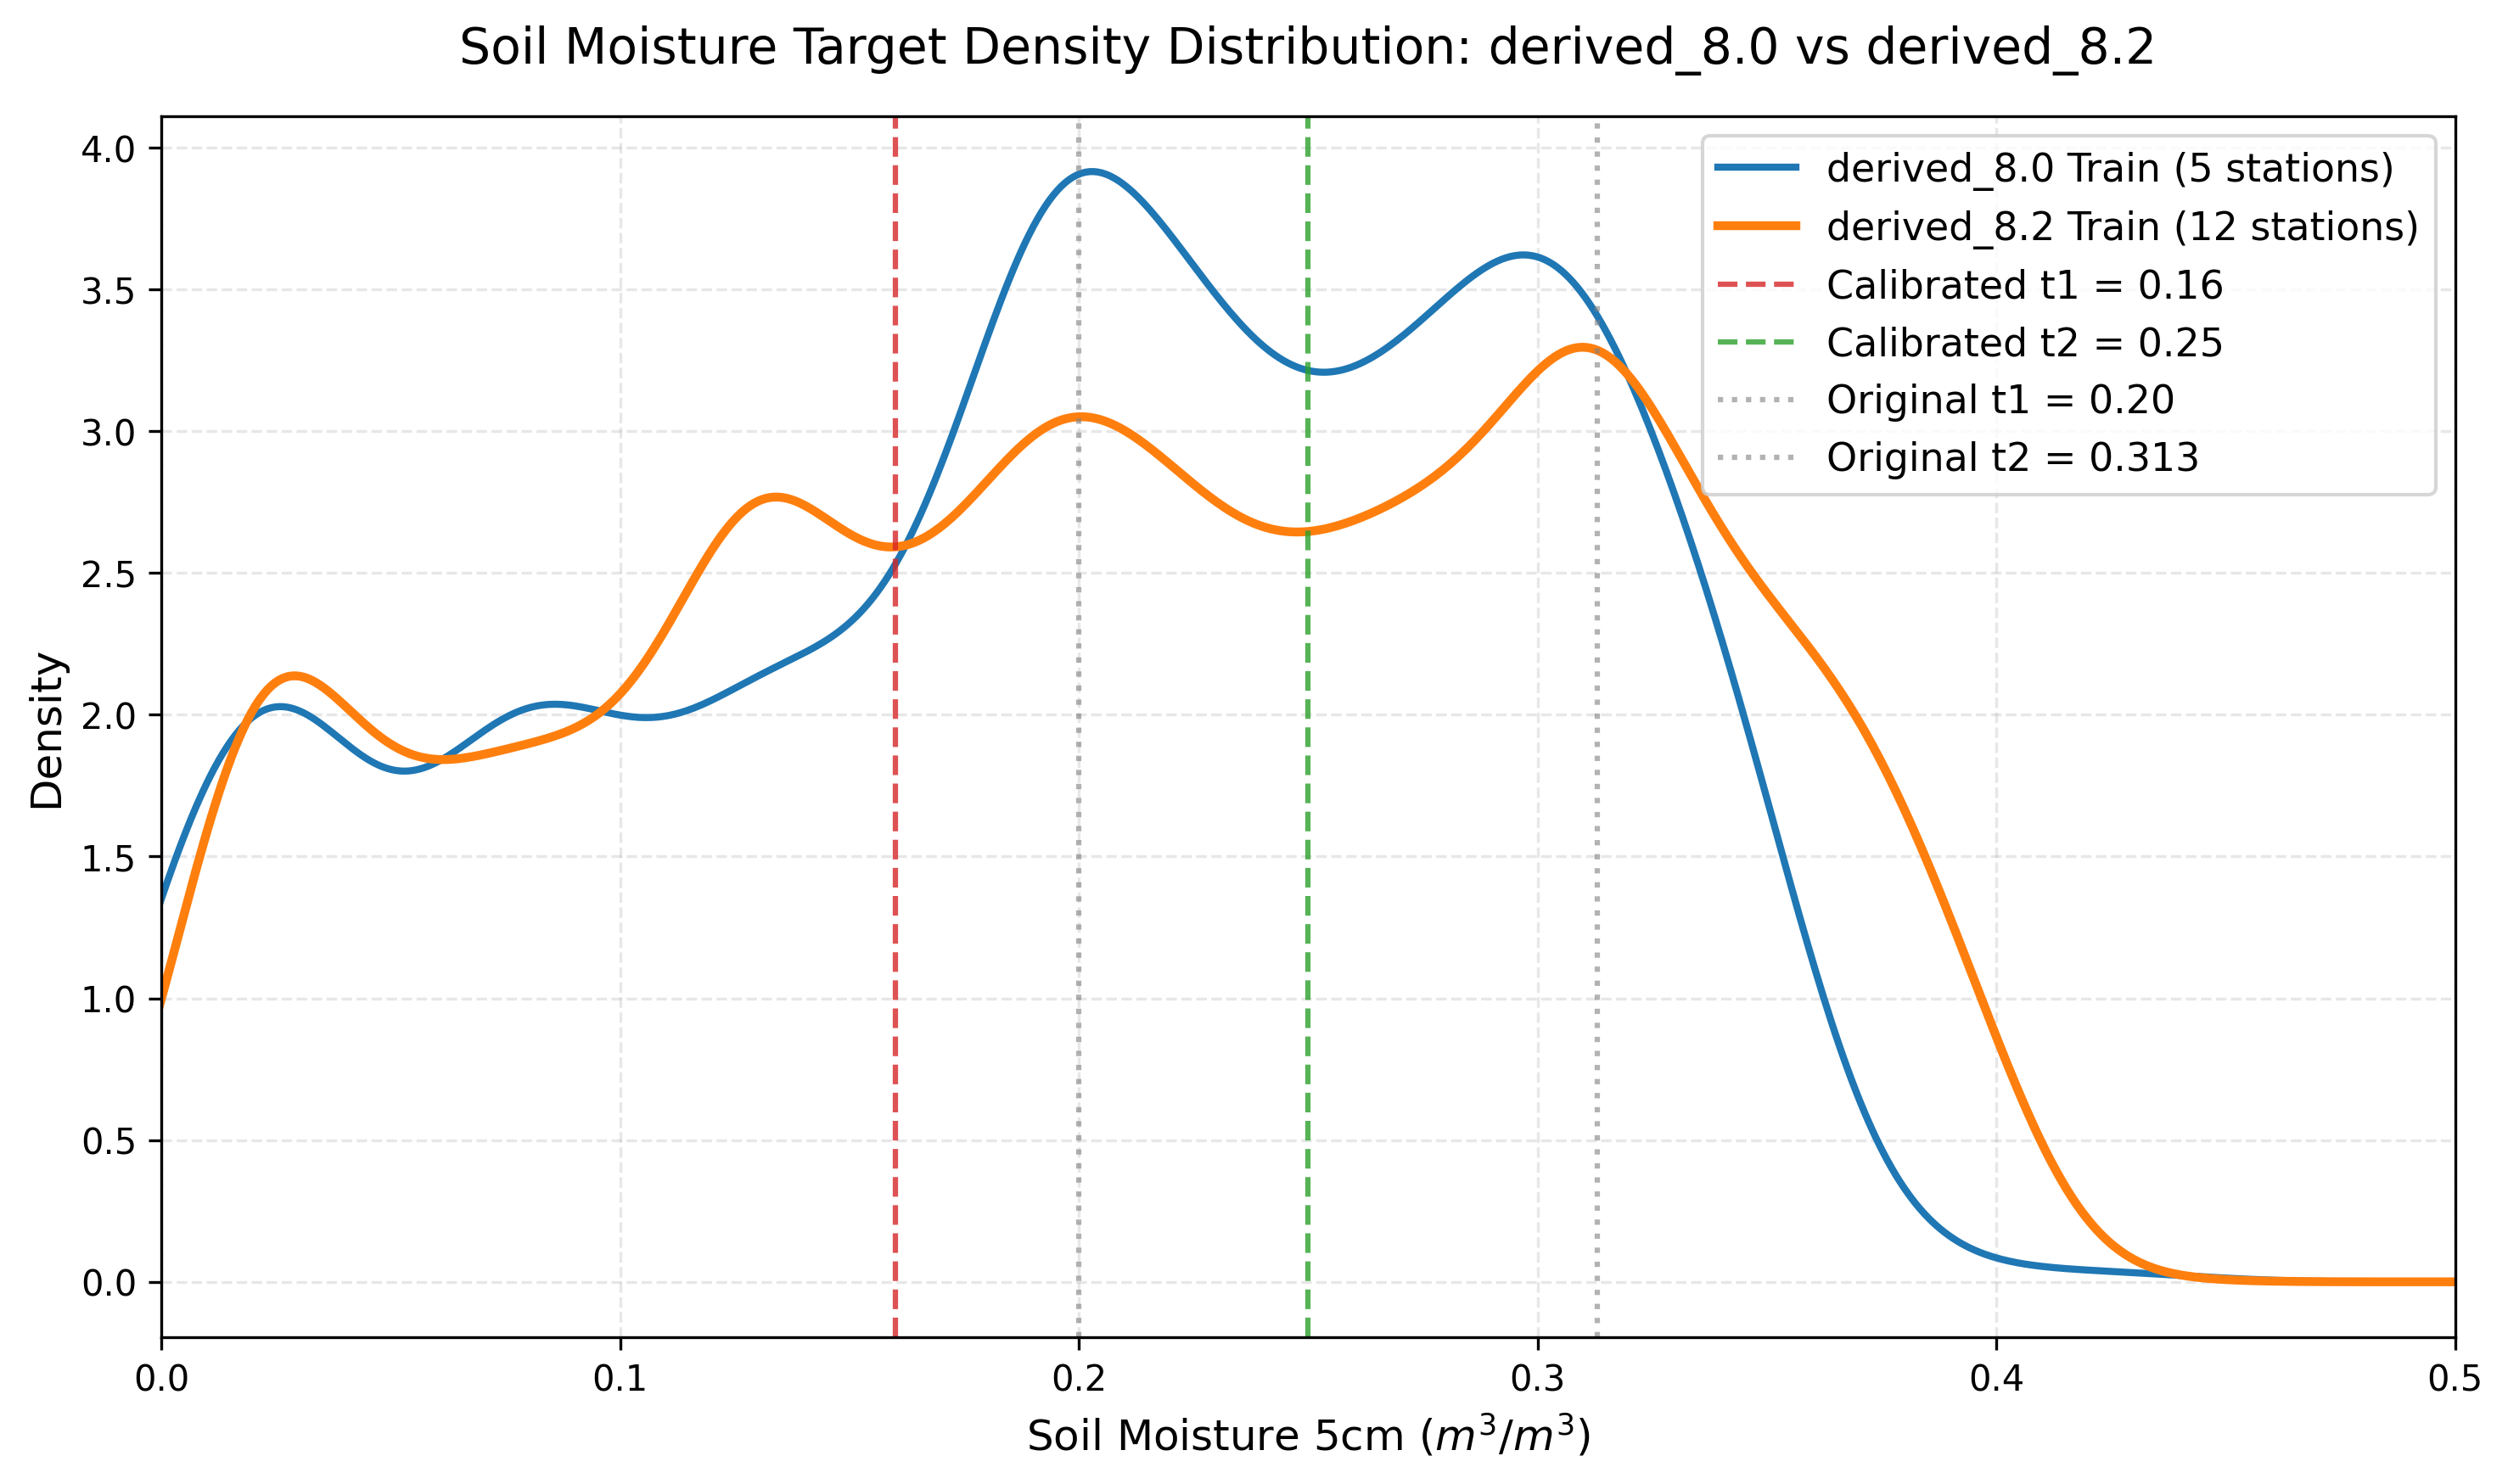

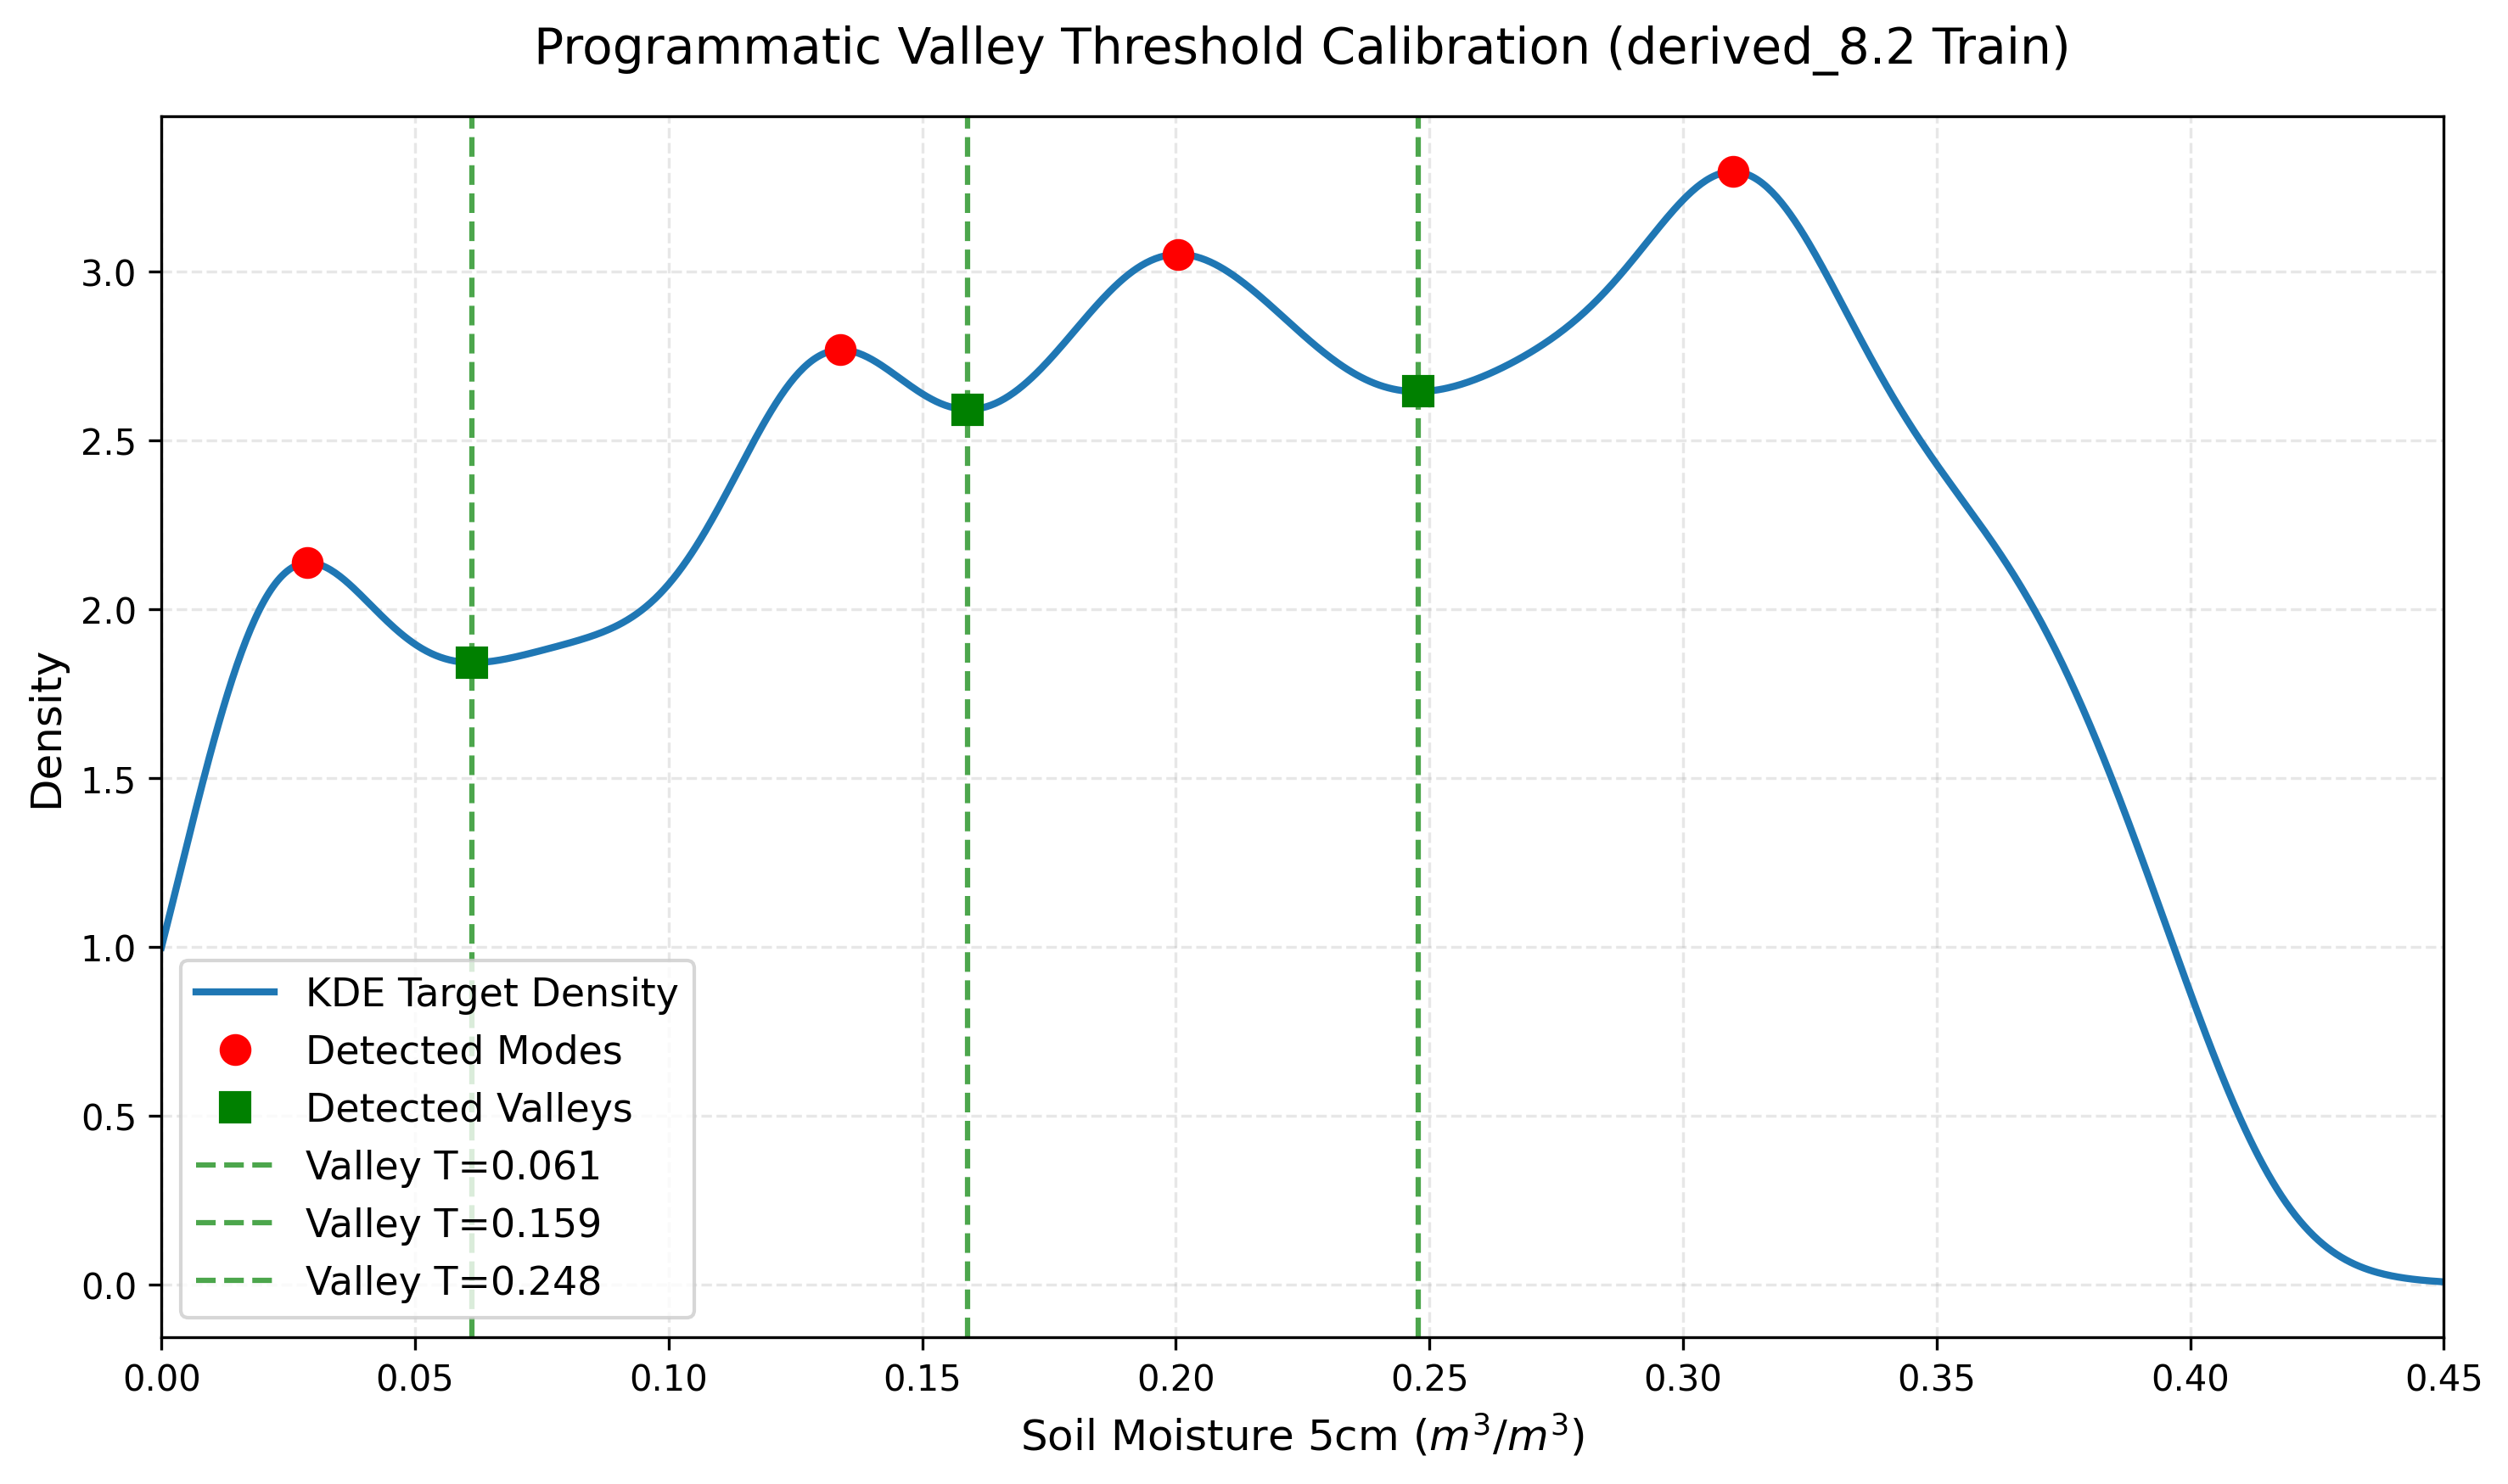

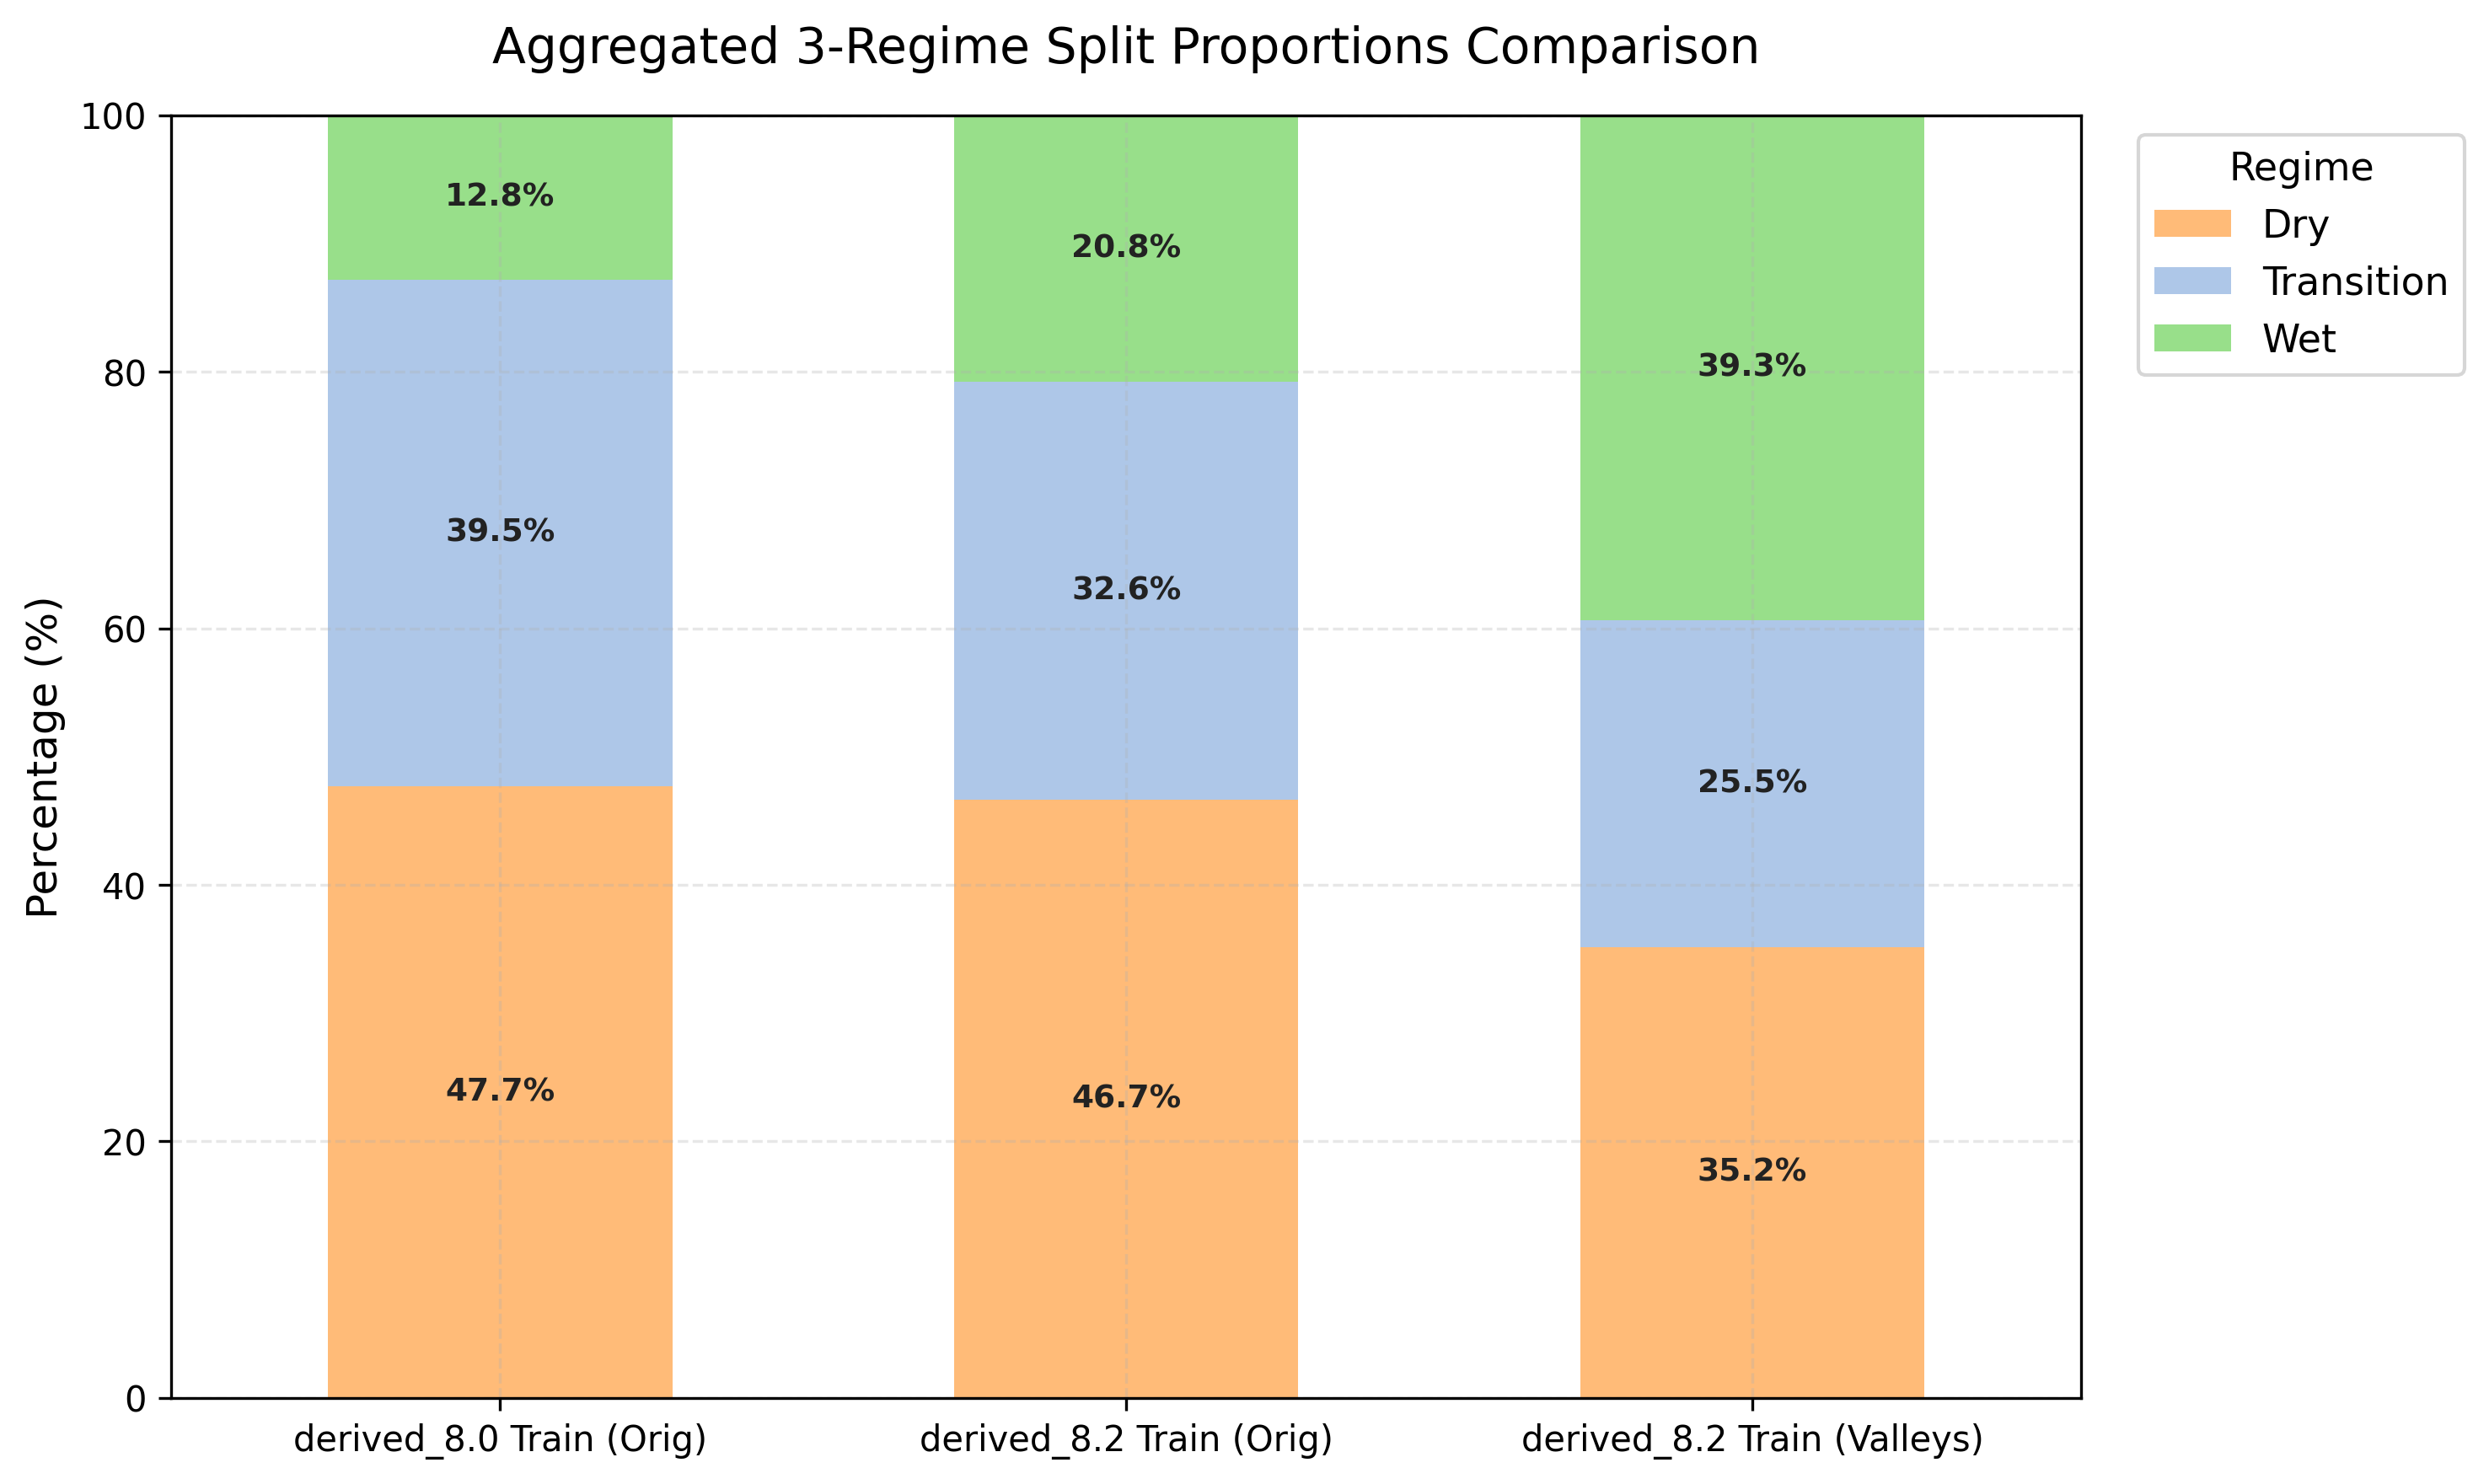

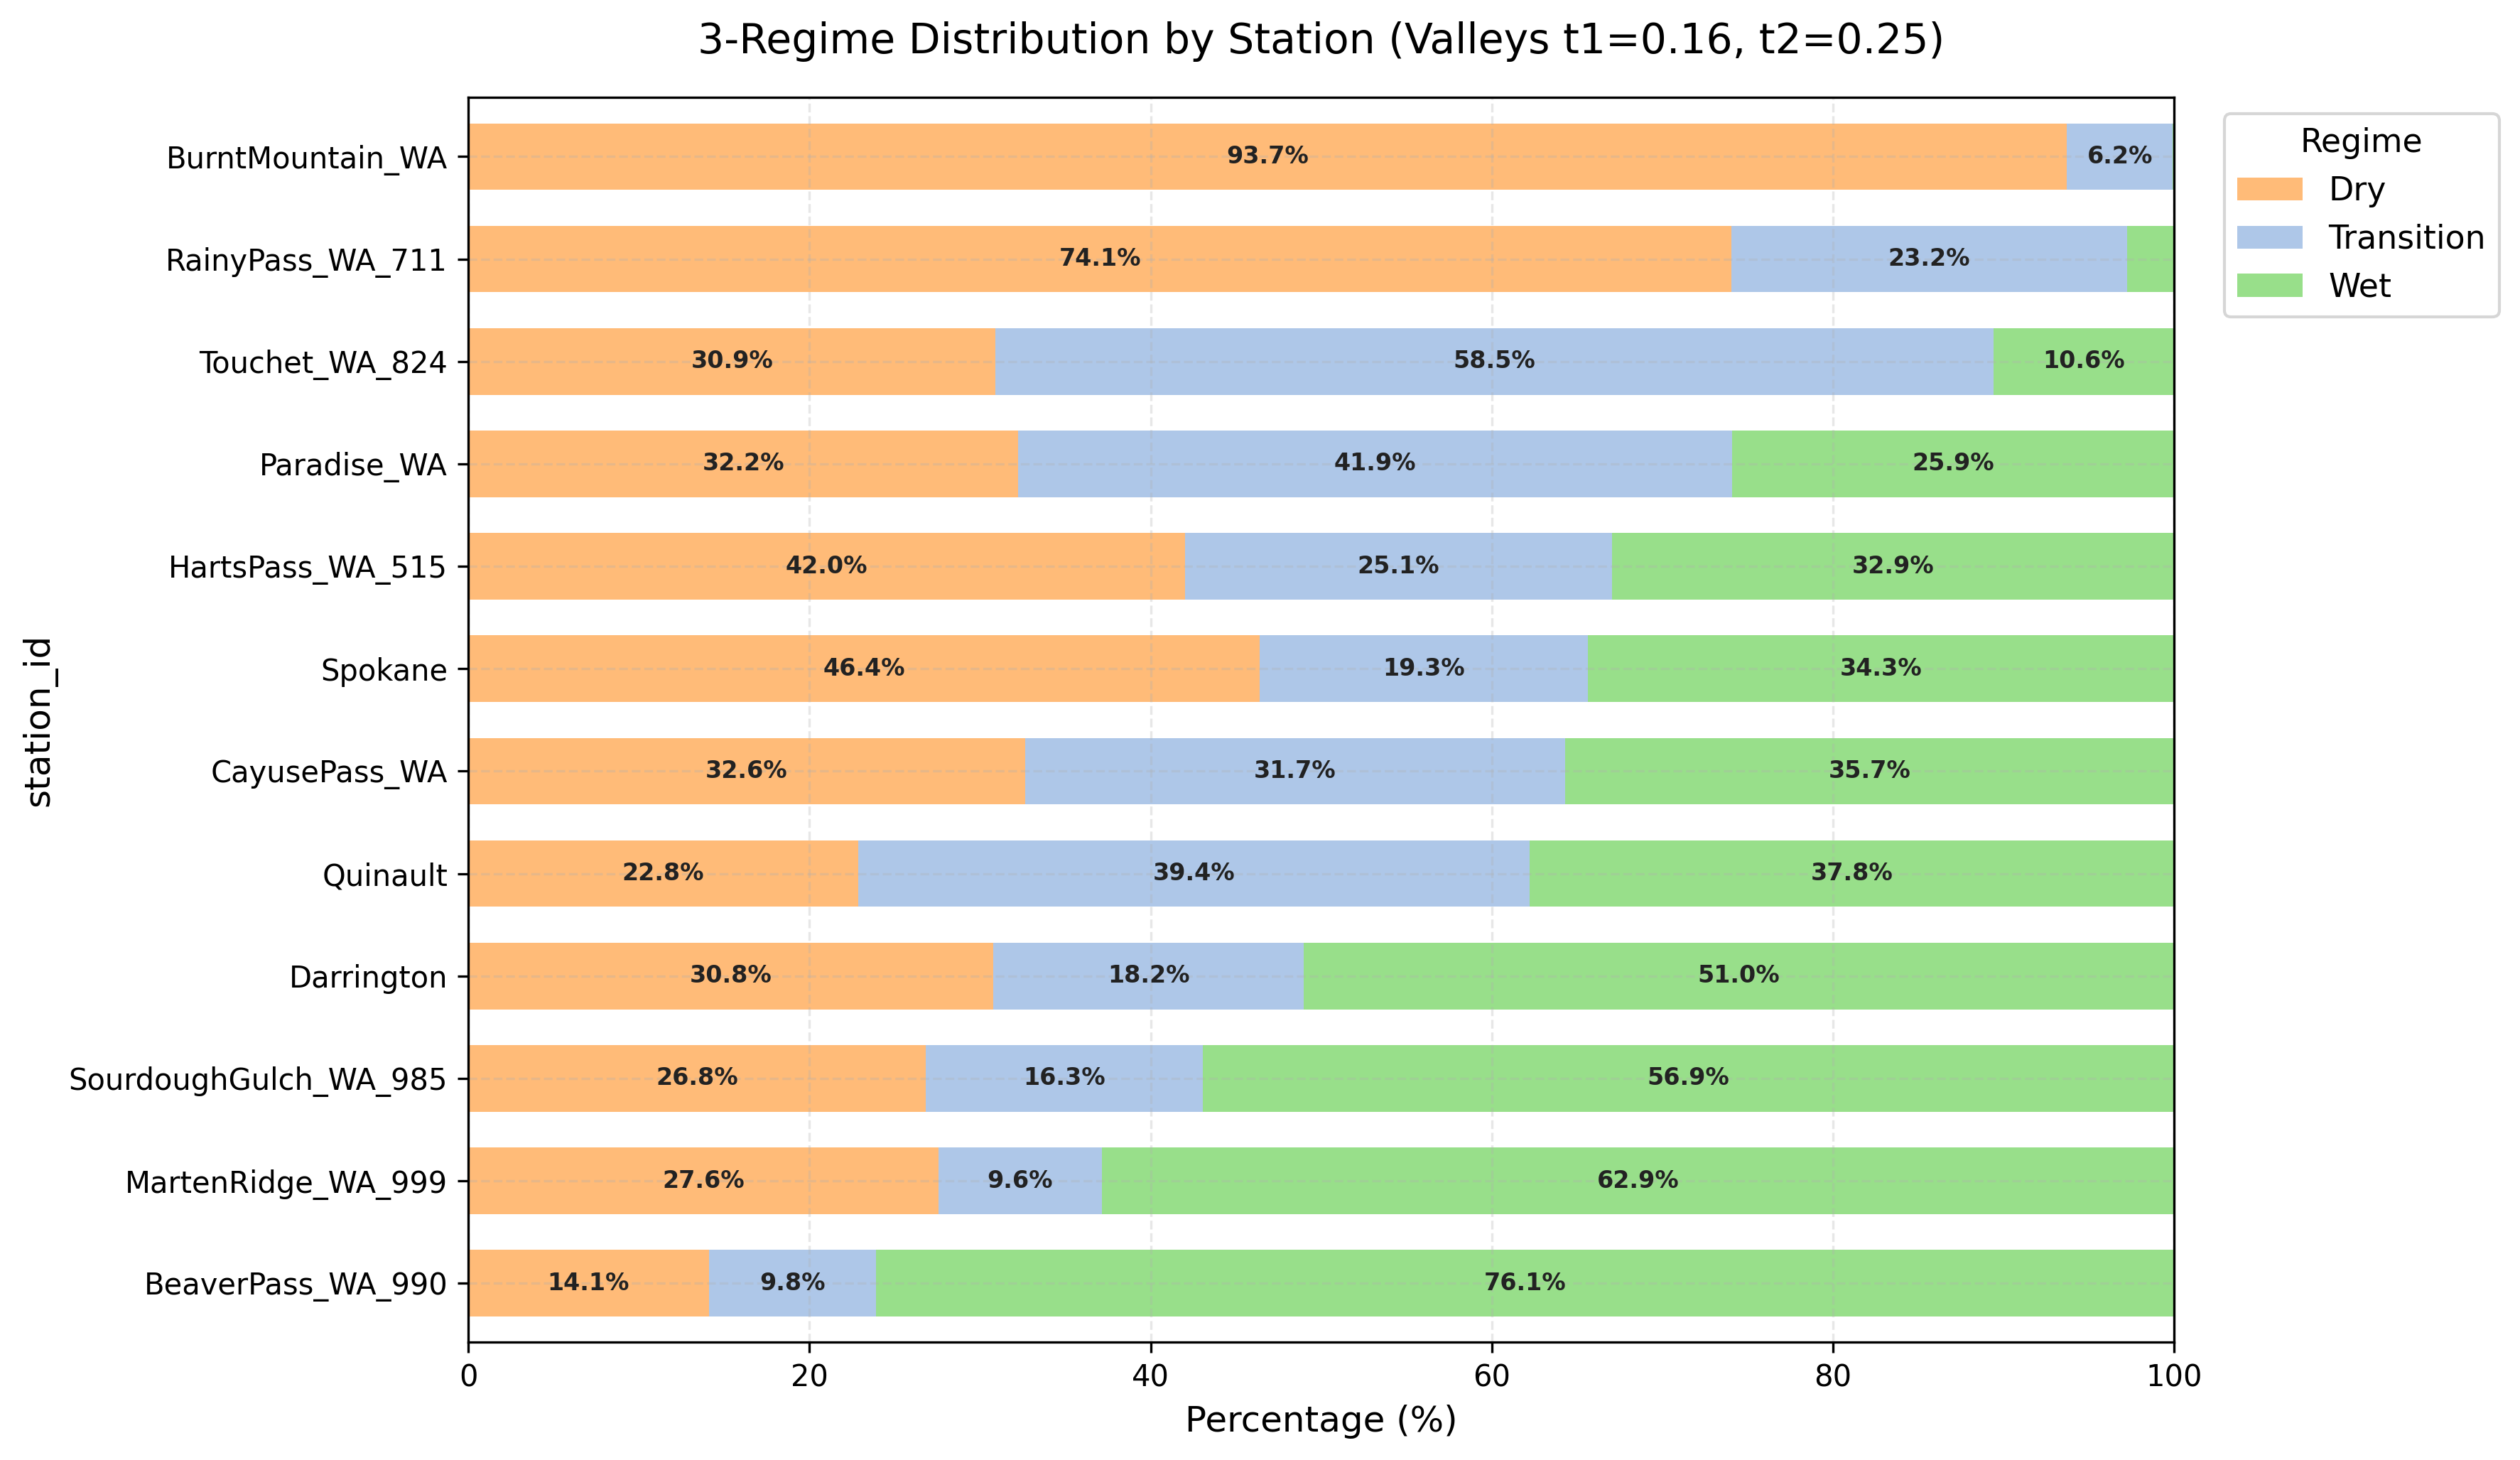

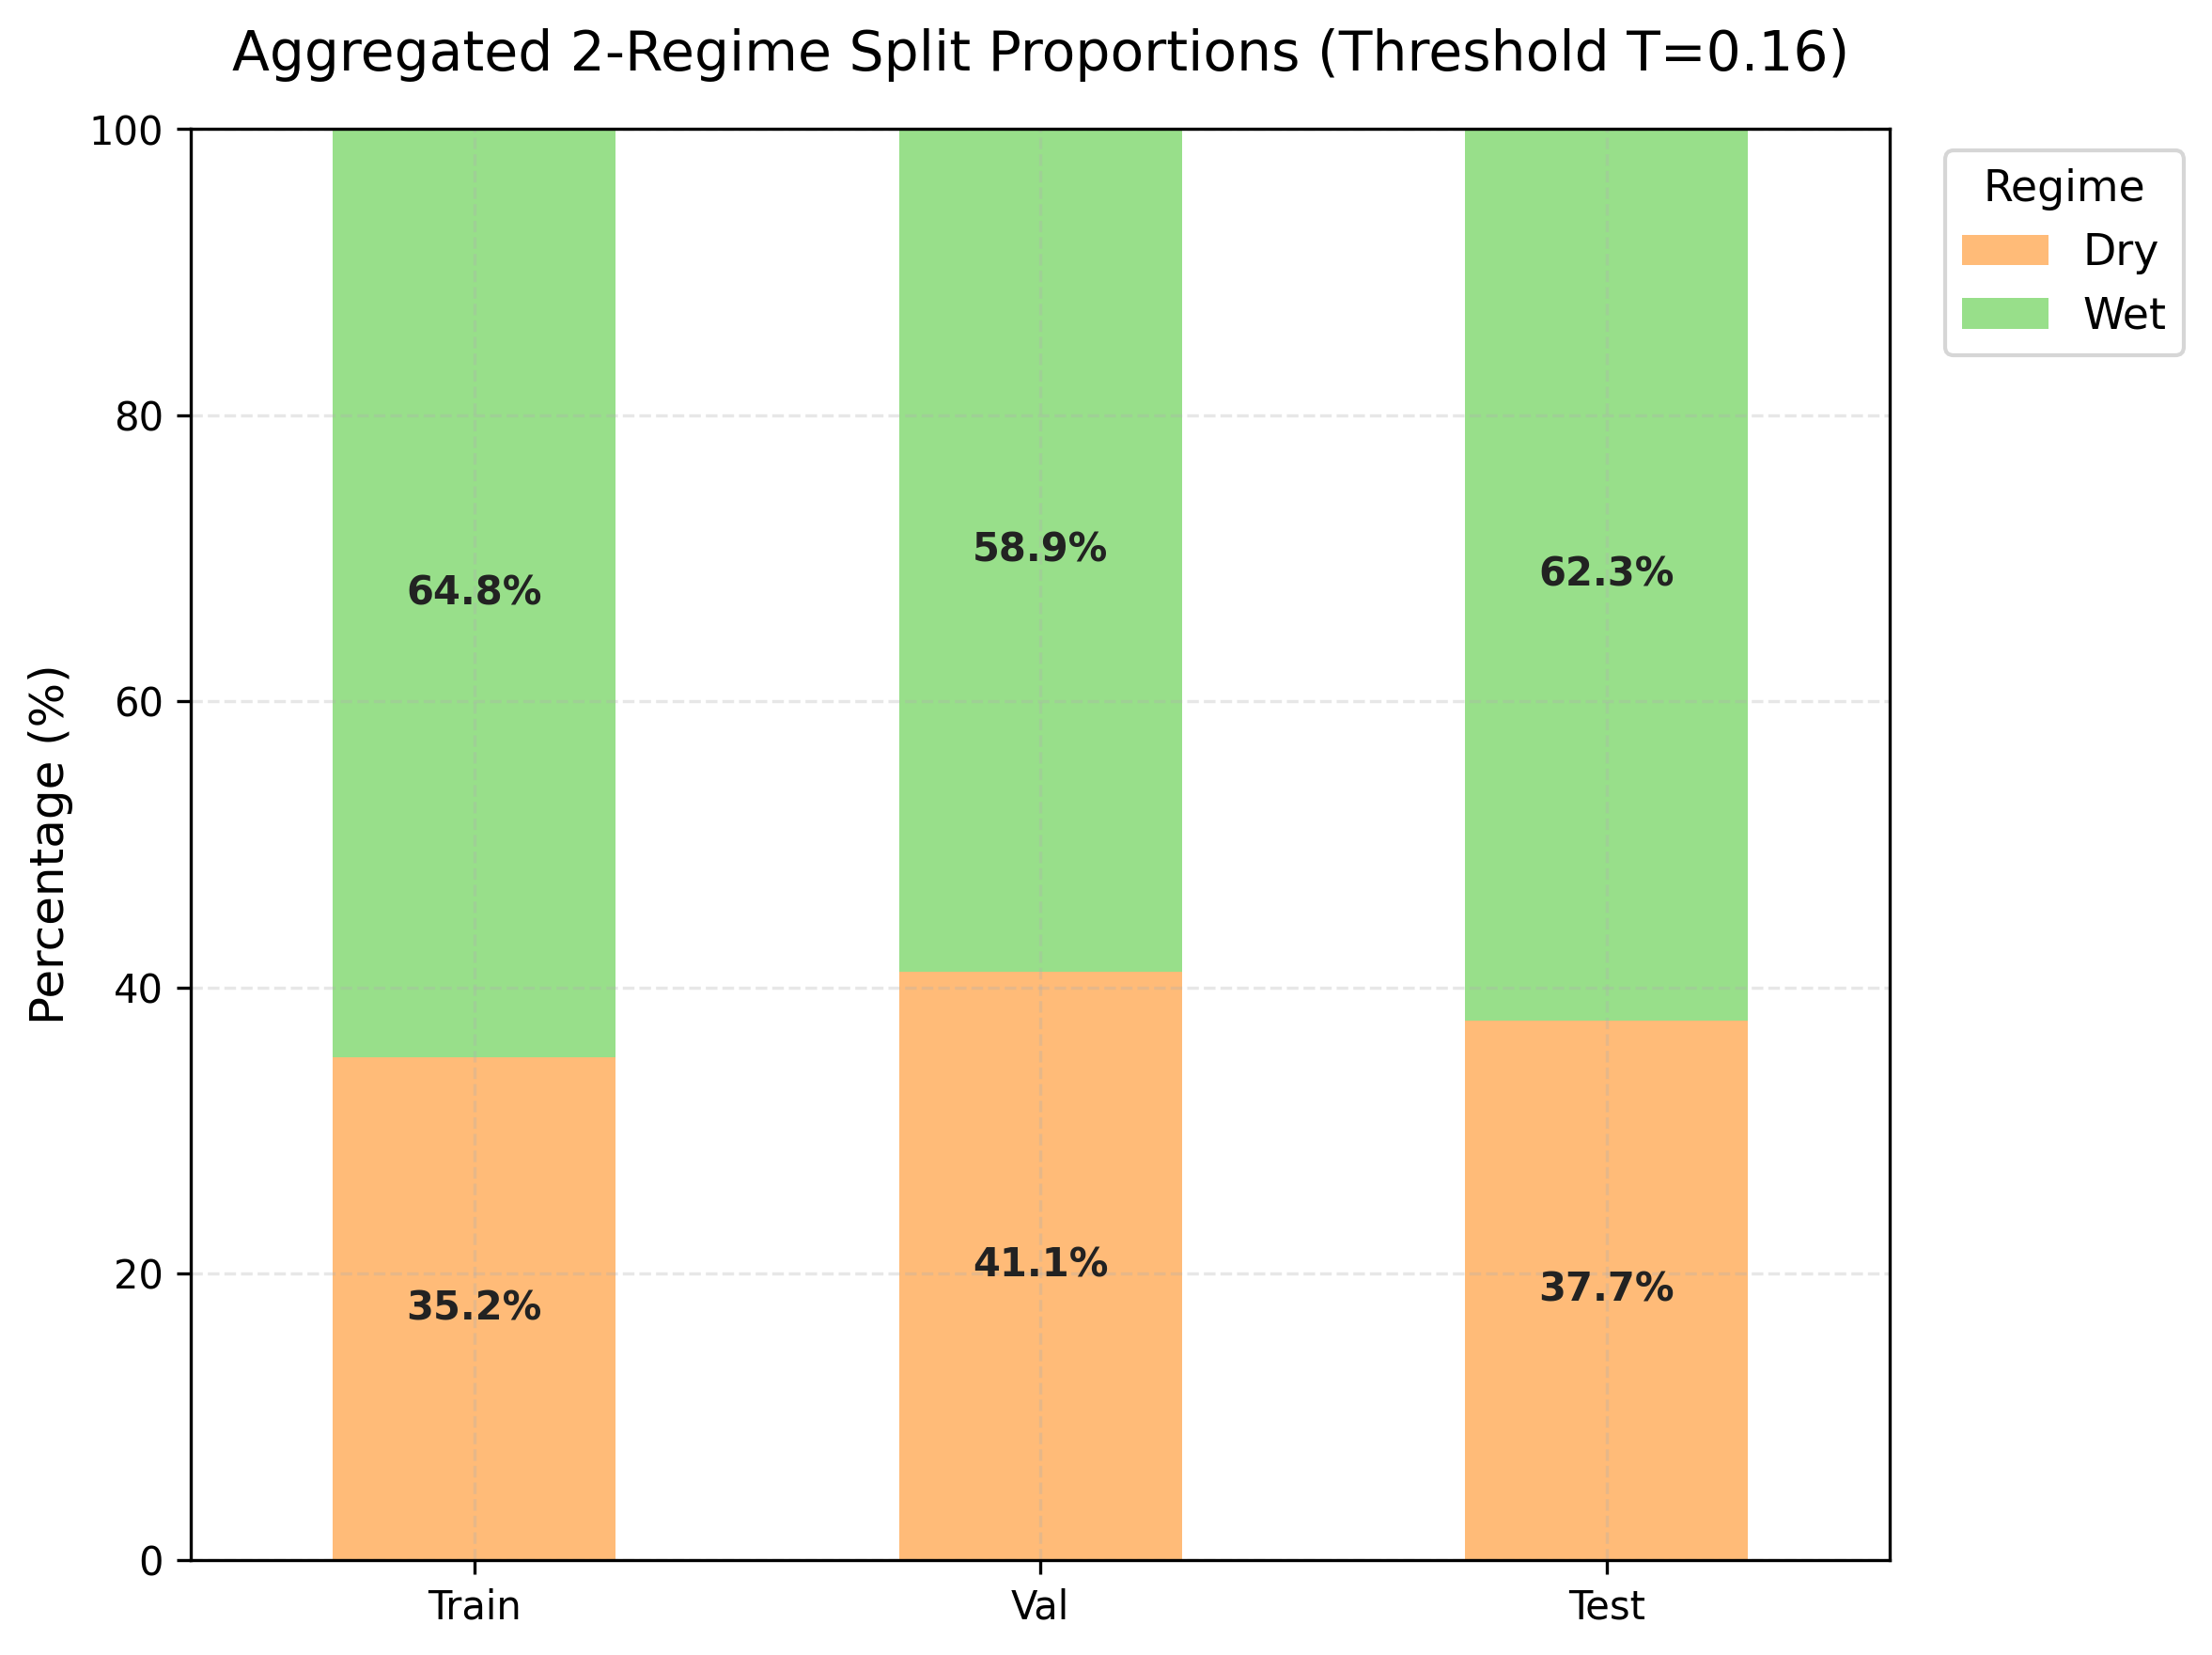

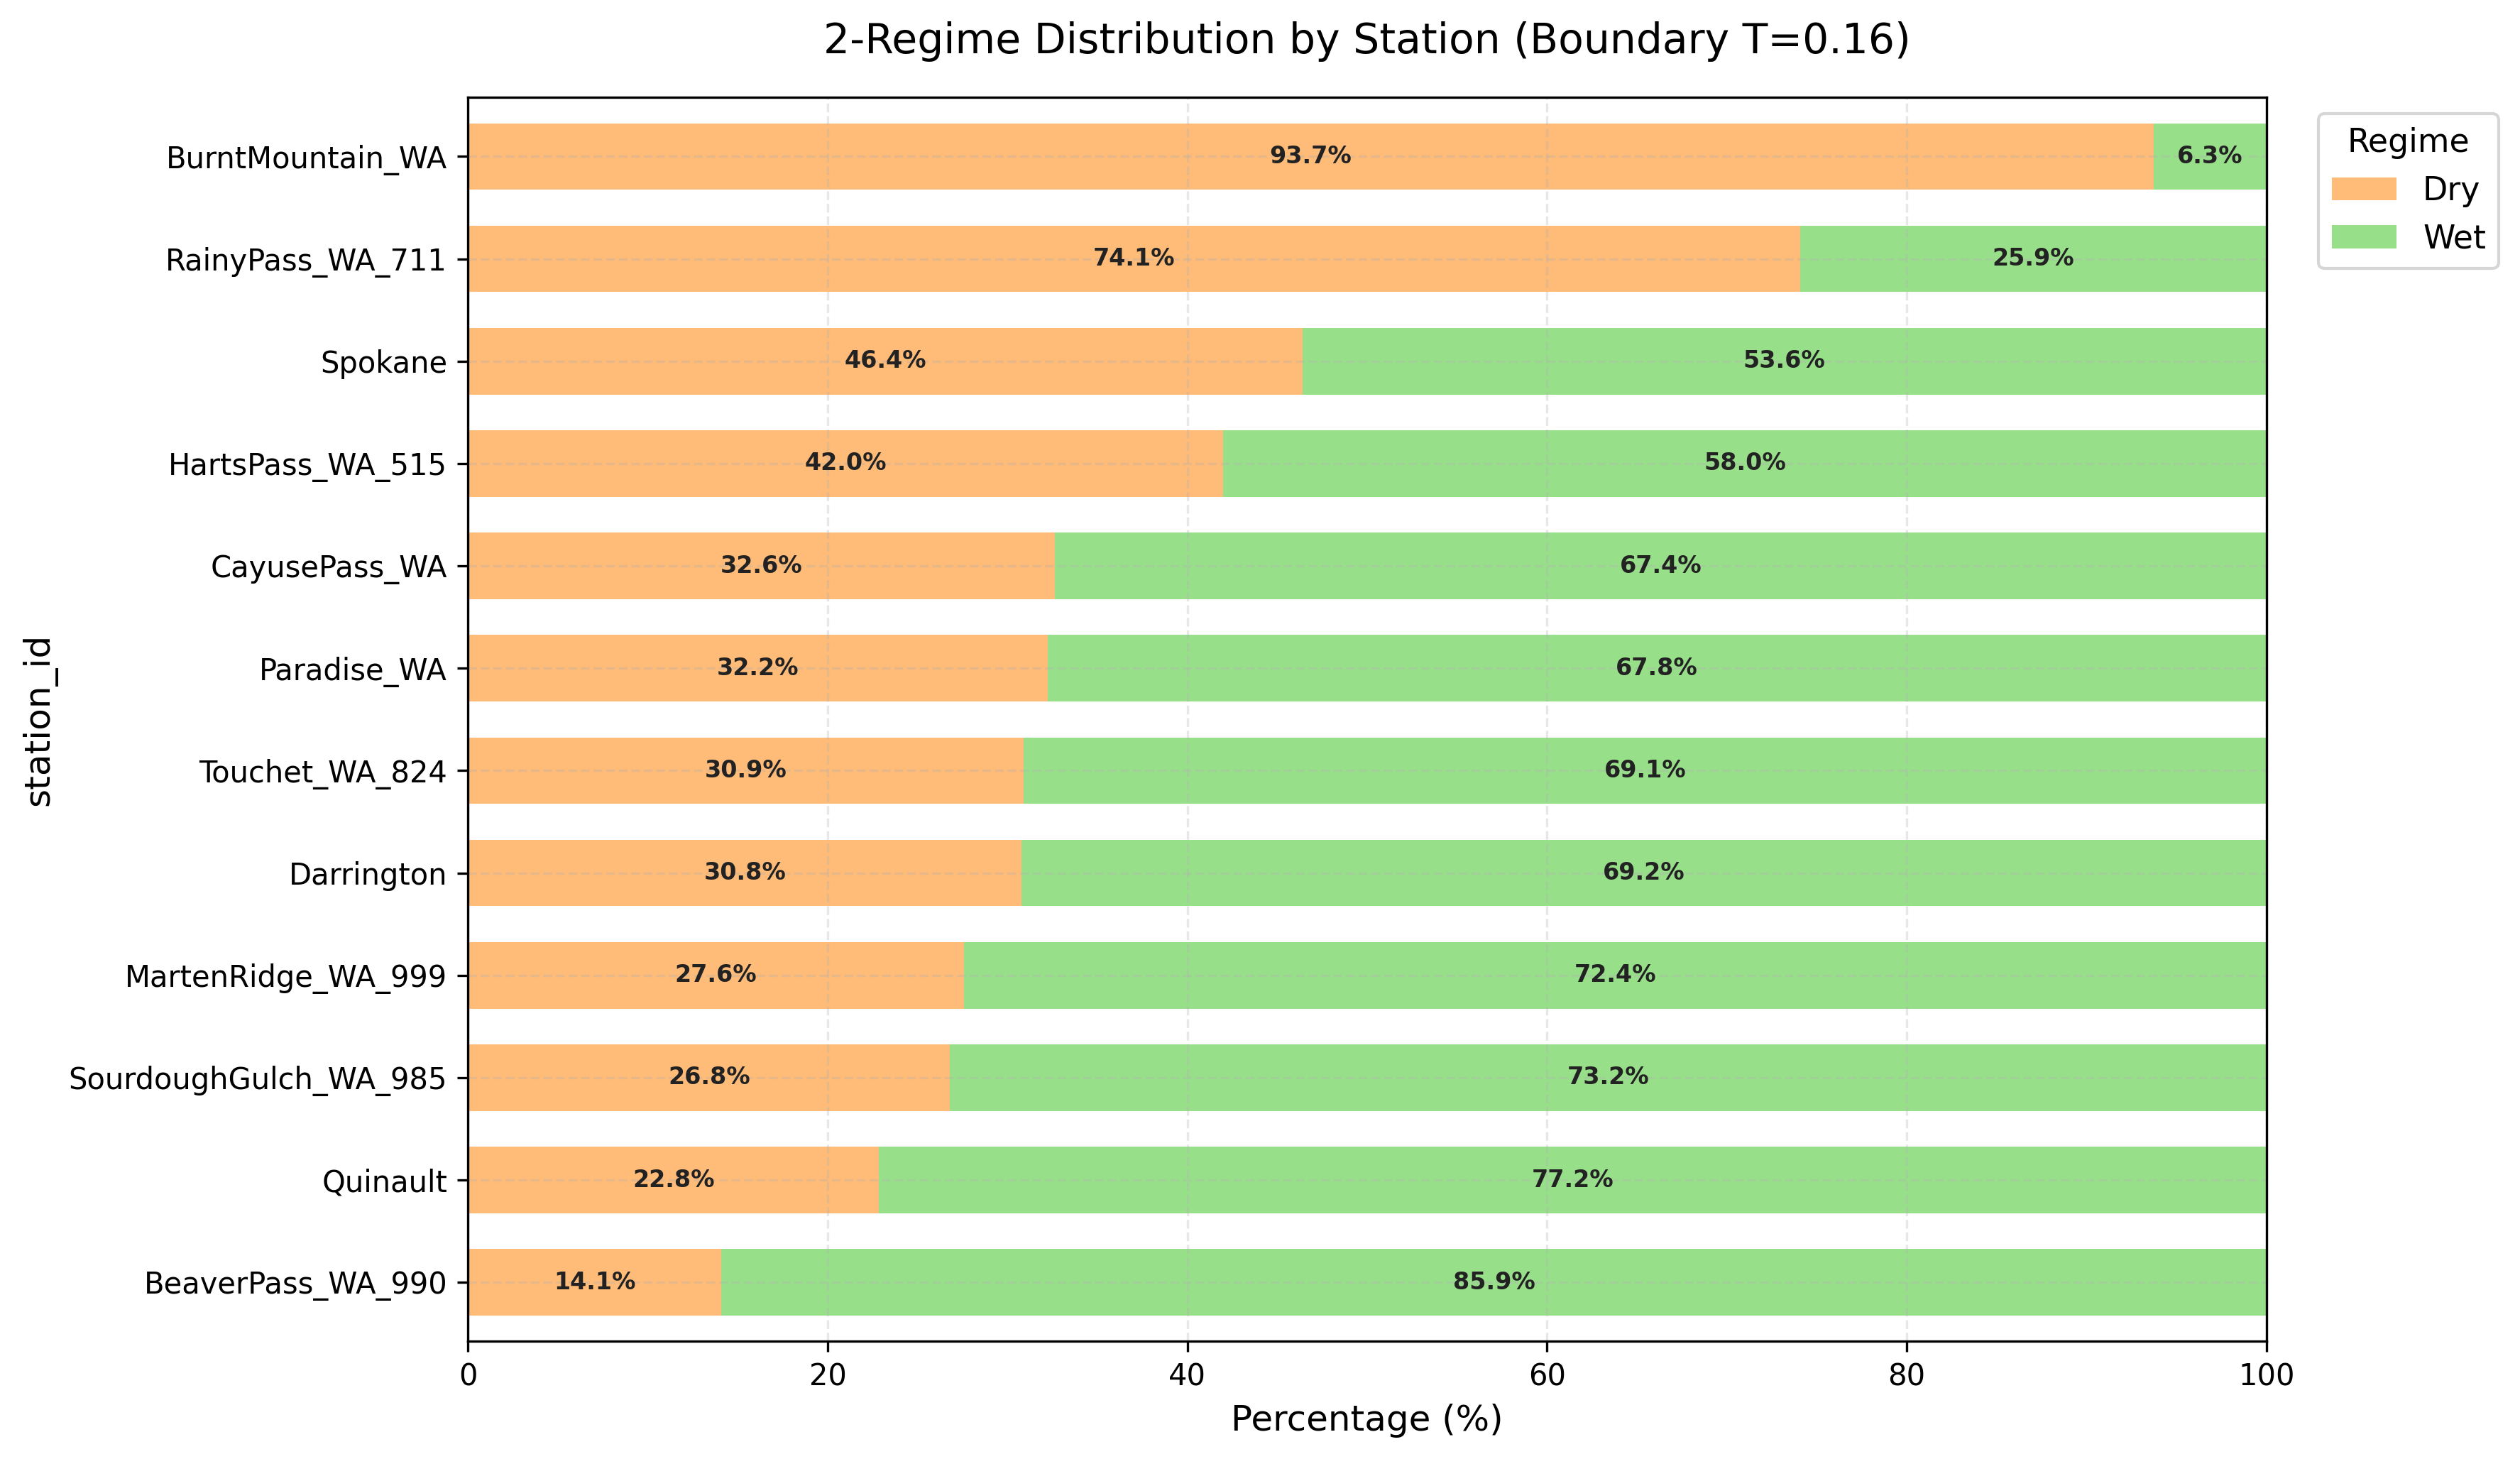

In [3]:
import calibrate_valleys
calibrate_valleys.main()

import analyze_regimes
analyze_regimes.main()

display(Image(os.path.join(nb_dir, 'soil_moisture_density_comparison.png')))
display(Image(os.path.join(nb_dir, 'programmatic_valleys_calibration.png')))
display(Image(os.path.join(nb_dir, 'aggregated_regime_comparison.png')))
display(Image(os.path.join(nb_dir, 'regime_distribution_by_station.png')))
display(Image(os.path.join(nb_dir, 'aggregated_regime_comparison_2r.png')))
display(Image(os.path.join(nb_dir, 'regime_distribution_by_station_2r.png')))

# 4. Soil Moisture vs. Precipitation Station Diagnostics

To investigate why models perform poorly on specific stations (`BurntMountain_WA`, `Touchet_WA_824`, `MartenRidge_WA_999`), we analyze the relationship between soil moisture and daily precipitation (`precip_mm`) as well as the Antecedent Precipitation Index (`G_API`).

Loading derived_8.2 data for Soil Moisture vs Precipitation analysis...



=== Station Soil Moisture vs Precipitation Diagnostics ===
           station_id  count  sm_mean  sm_median   sm_std  precip_mean  api_mean  corr_prcp  corr_api  near_zero_pct  high_p_low_sm_count  model_r2
    BeaverPass_WA_990   2811 0.277256      0.313 0.099947     5.042191 50.315661   0.115559  0.342475       0.106724                    9     0.681
     BurntMountain_WA   1483 0.073266      0.076 0.050413     6.132637 63.636557  -0.003659  0.104228      11.126096                  131    -0.783
        CayusePass_WA   3123 0.196040      0.216 0.113828     4.622446 46.192438   0.083803  0.263413       4.066603                   37     0.690
           Darrington   3047 0.219232      0.252 0.104517     6.211618 62.106249   0.399132  0.717160       0.000000                    9     0.785
     HartsPass_WA_515   1600 0.192145      0.175 0.111018     3.306813 32.980375  -0.070887 -0.067334       1.375000                    6     0.540
   MartenRidge_WA_999   2957 0.256506      0.319 0.1

Saved Soil Moisture vs Precipitation diagnostic figures successfully!


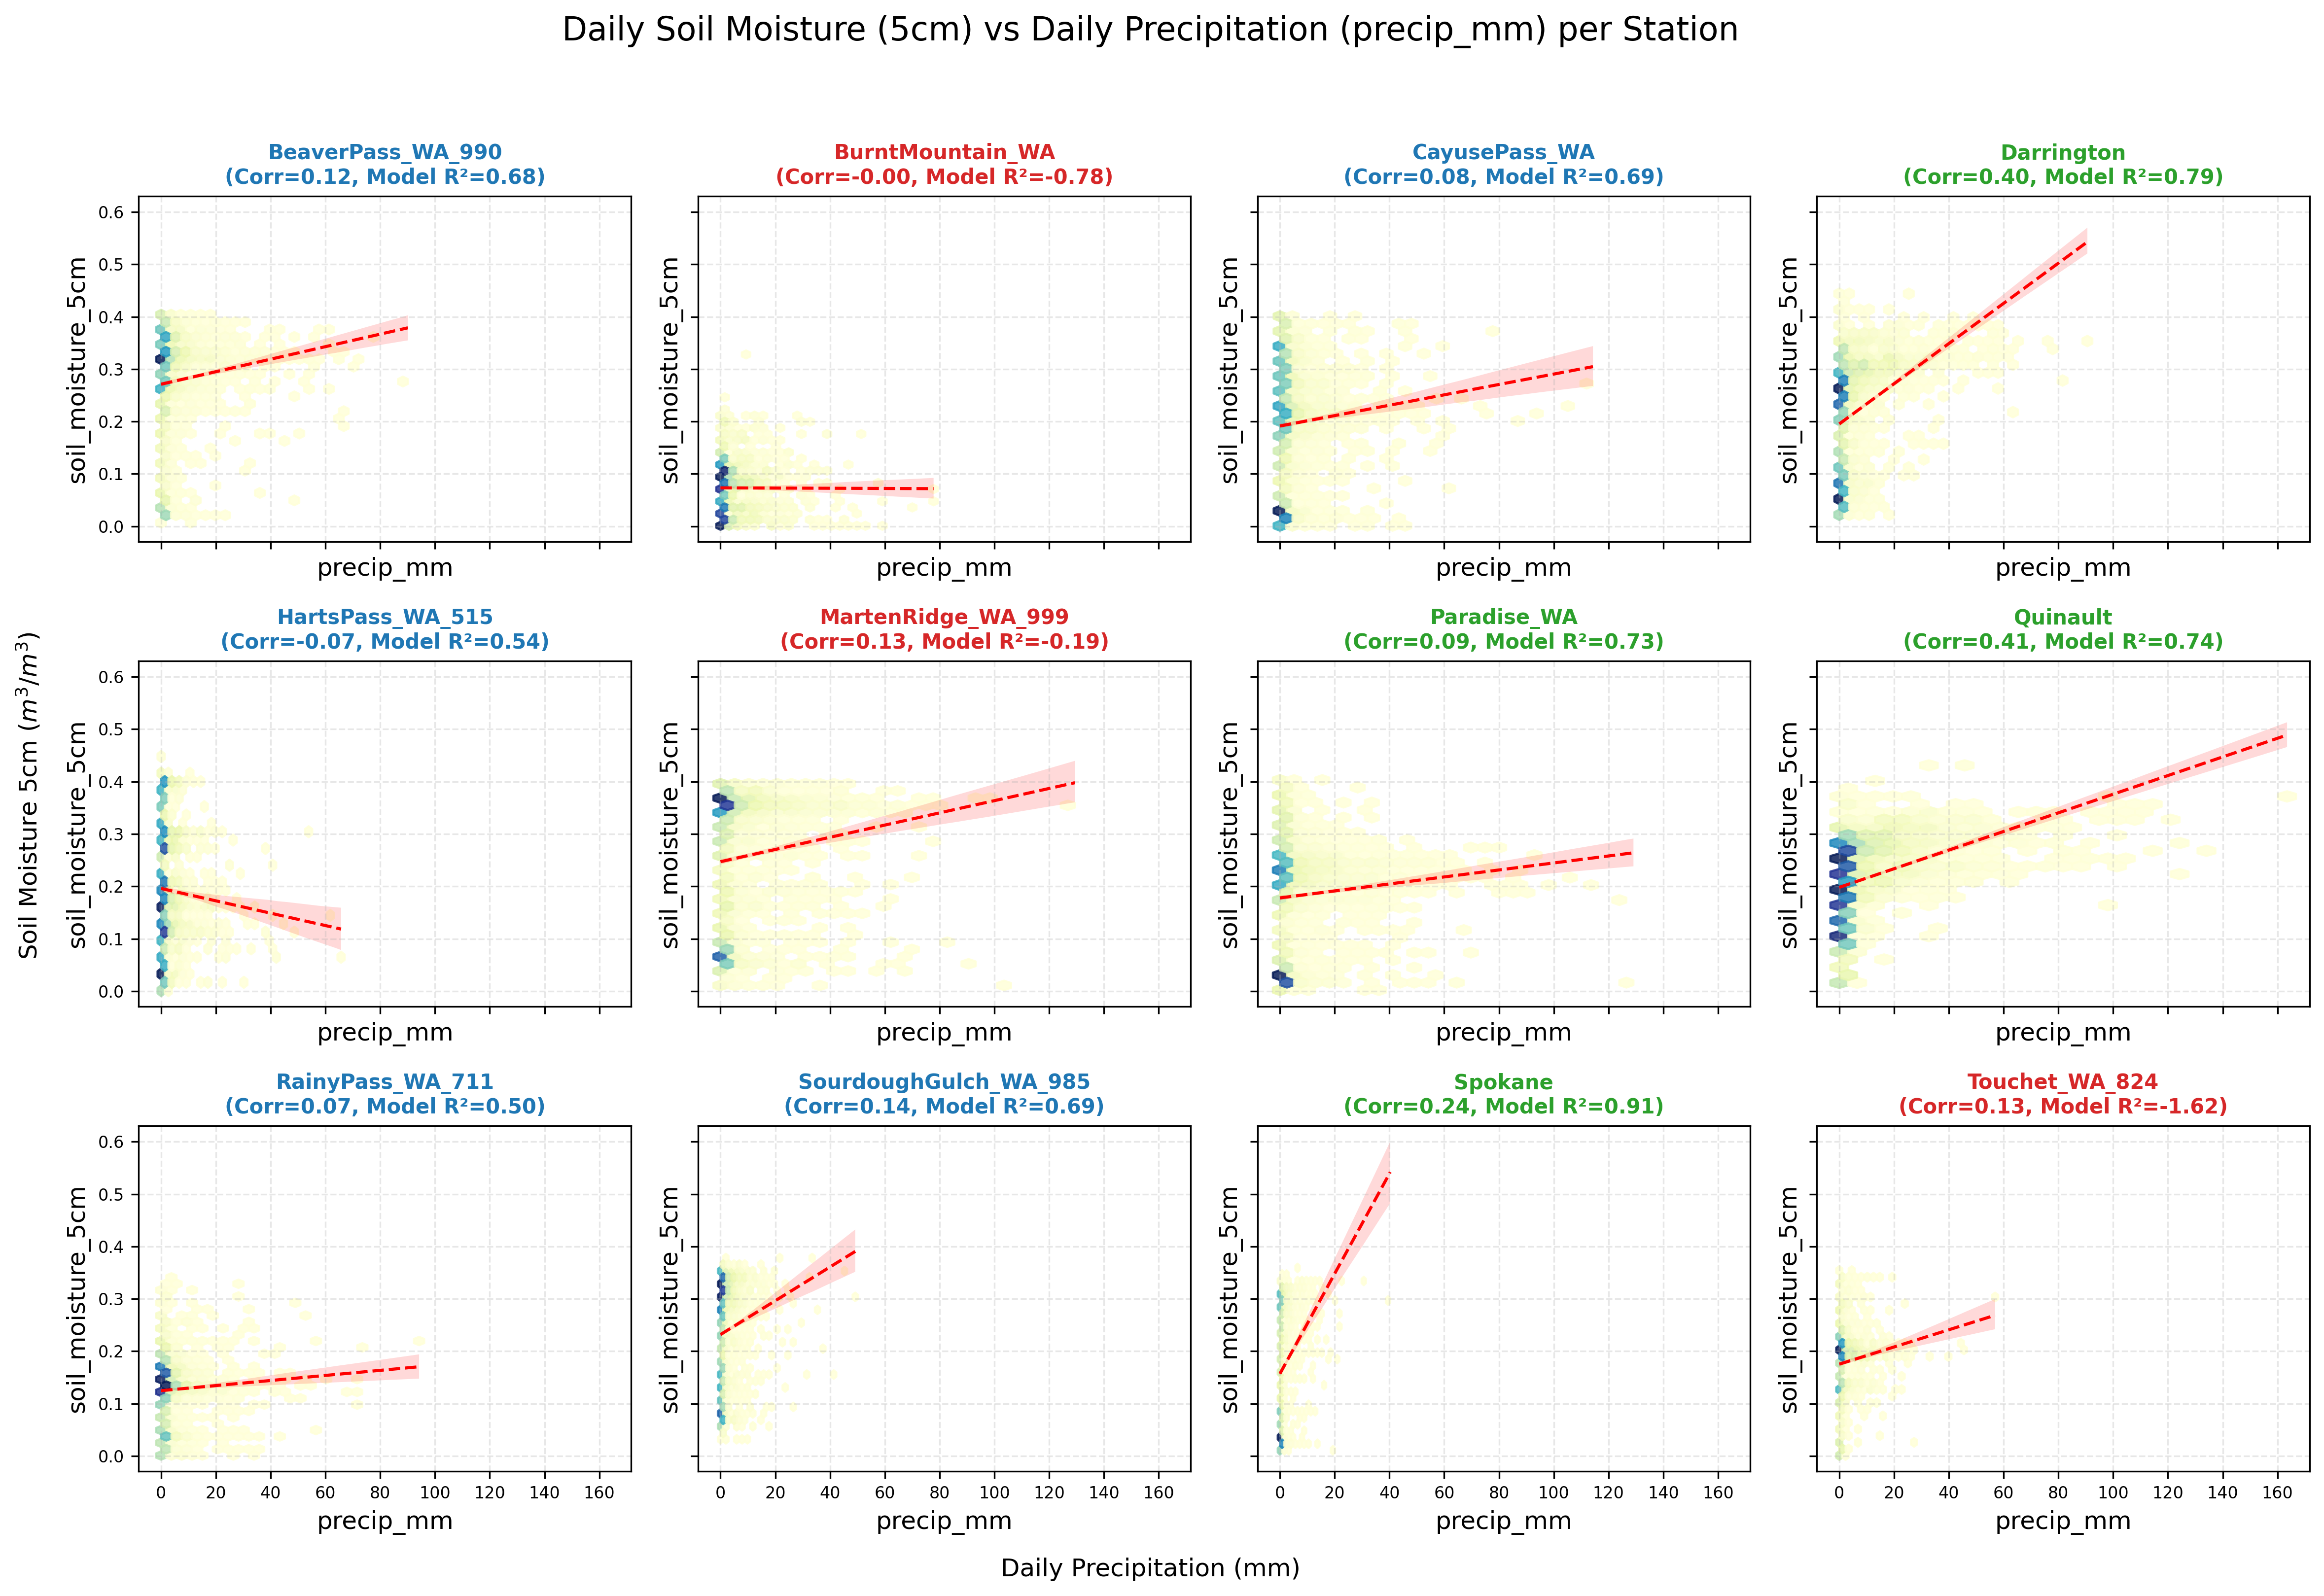

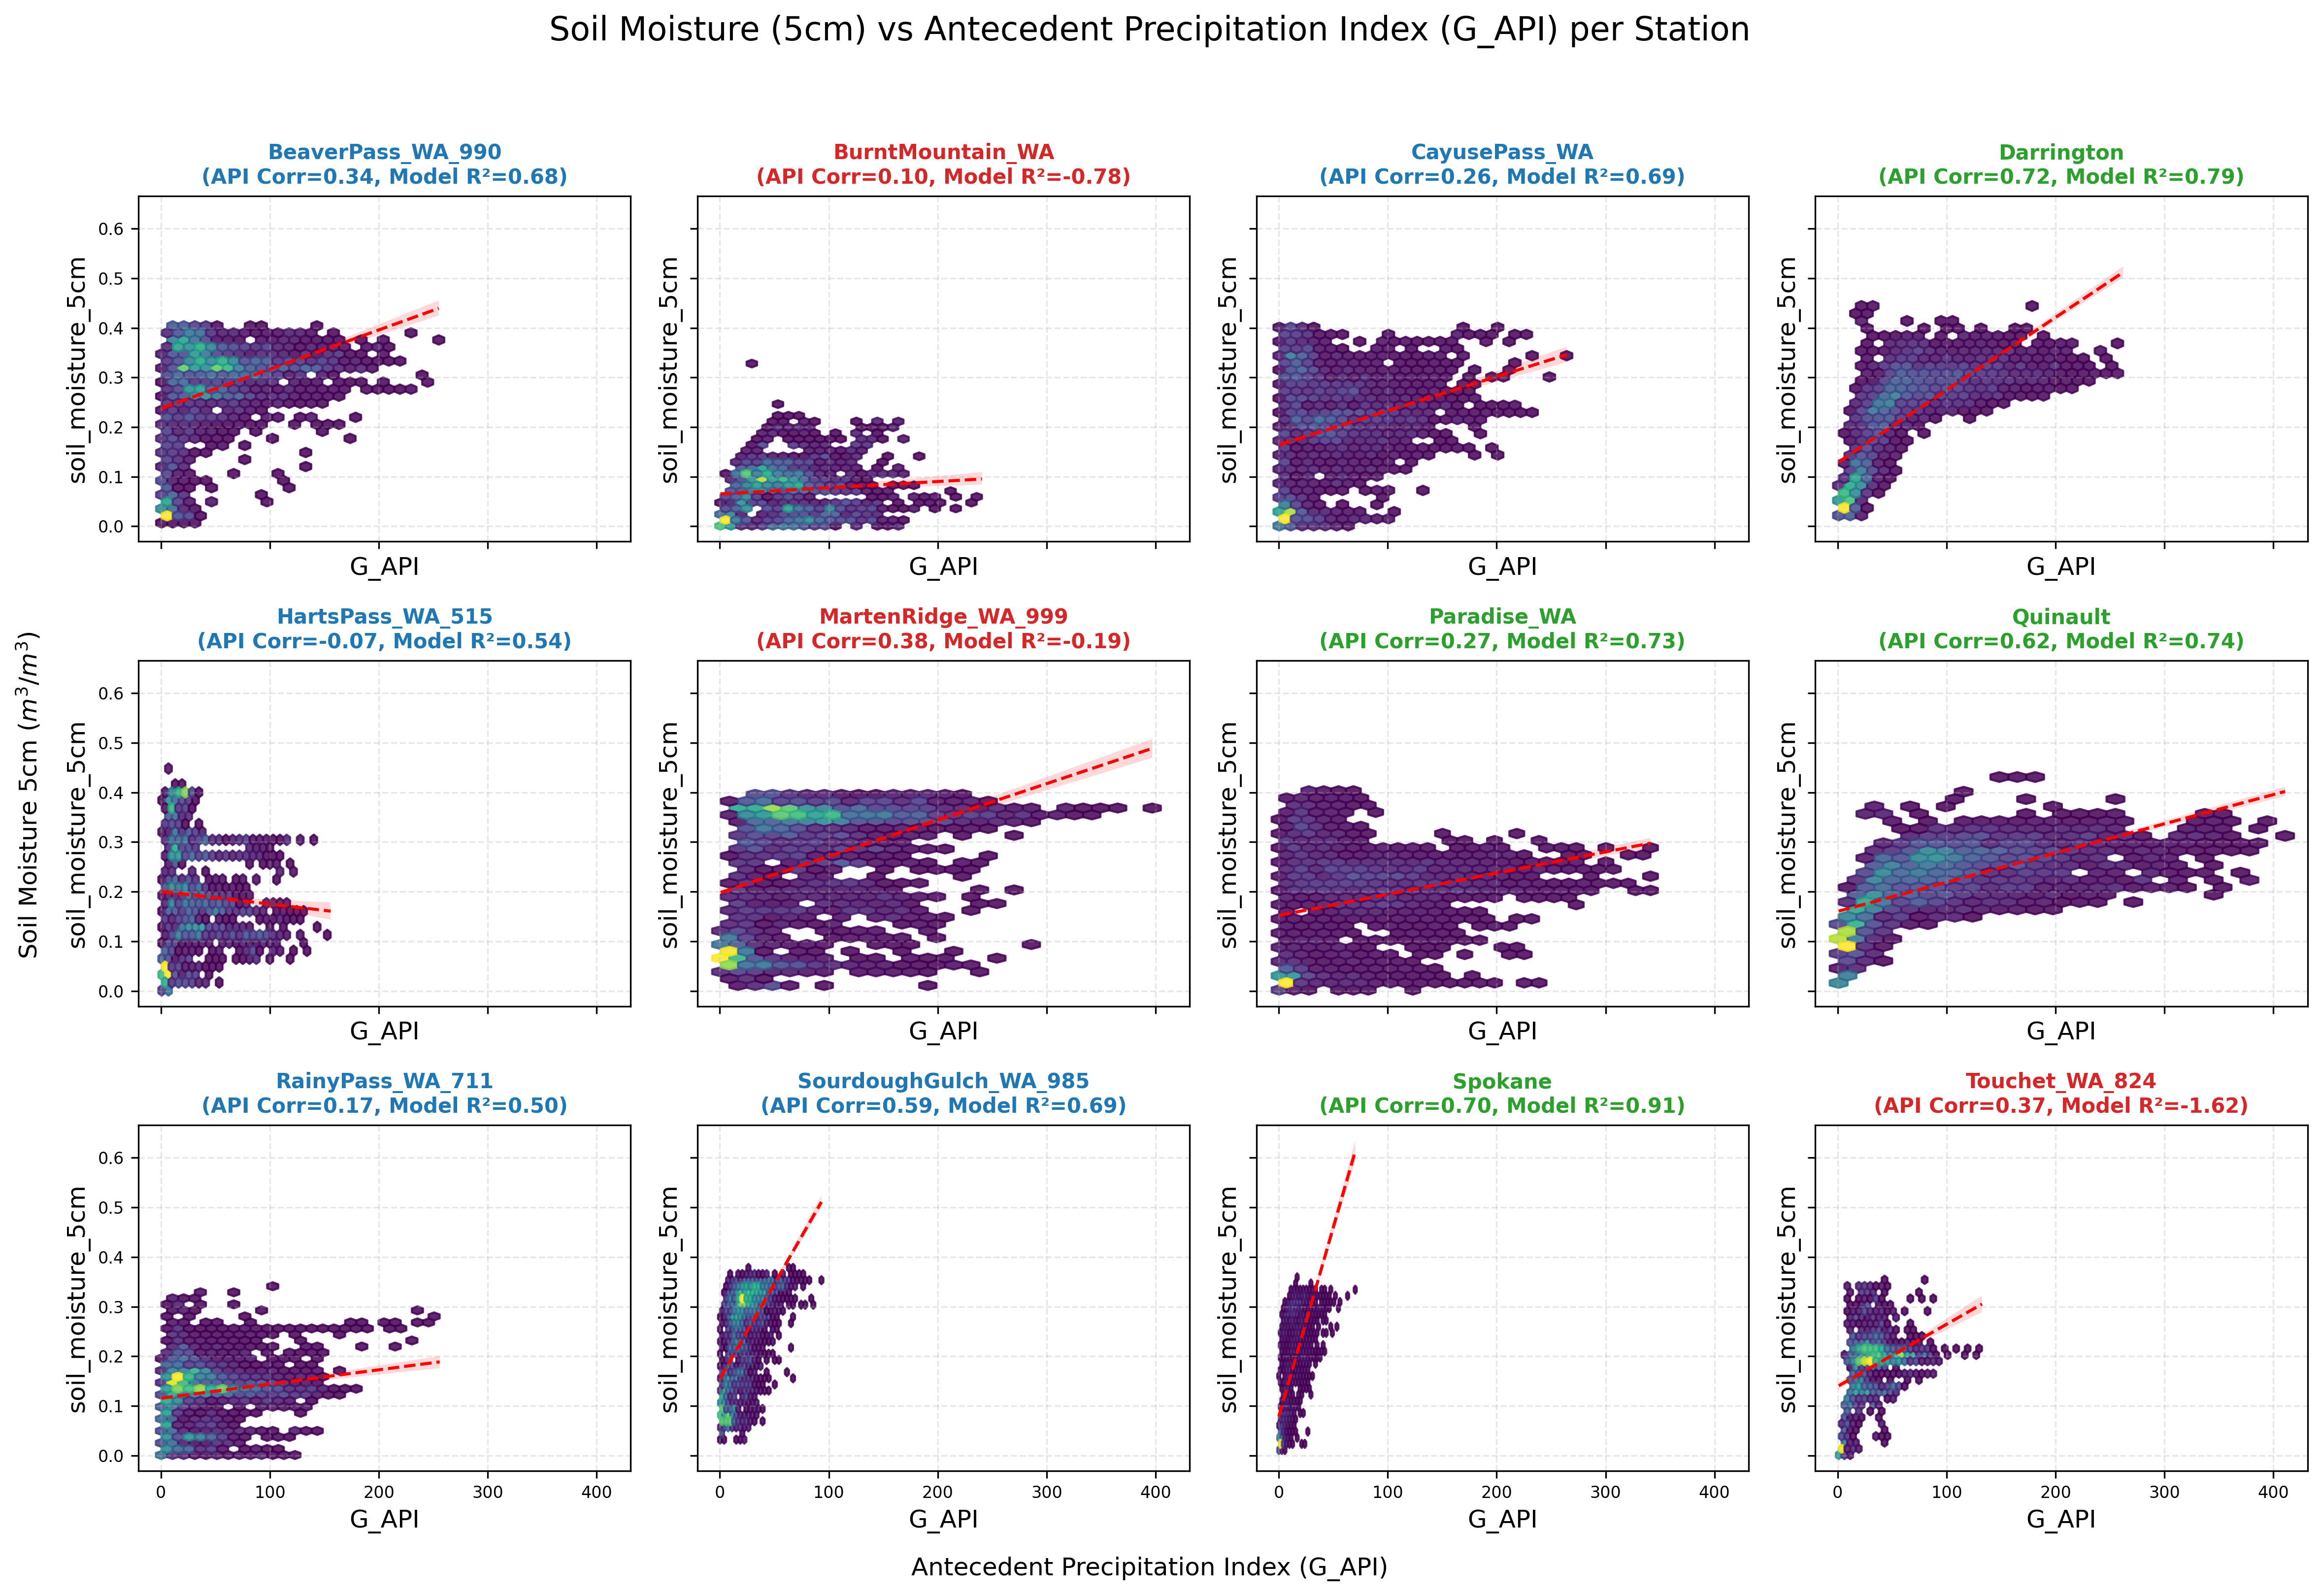

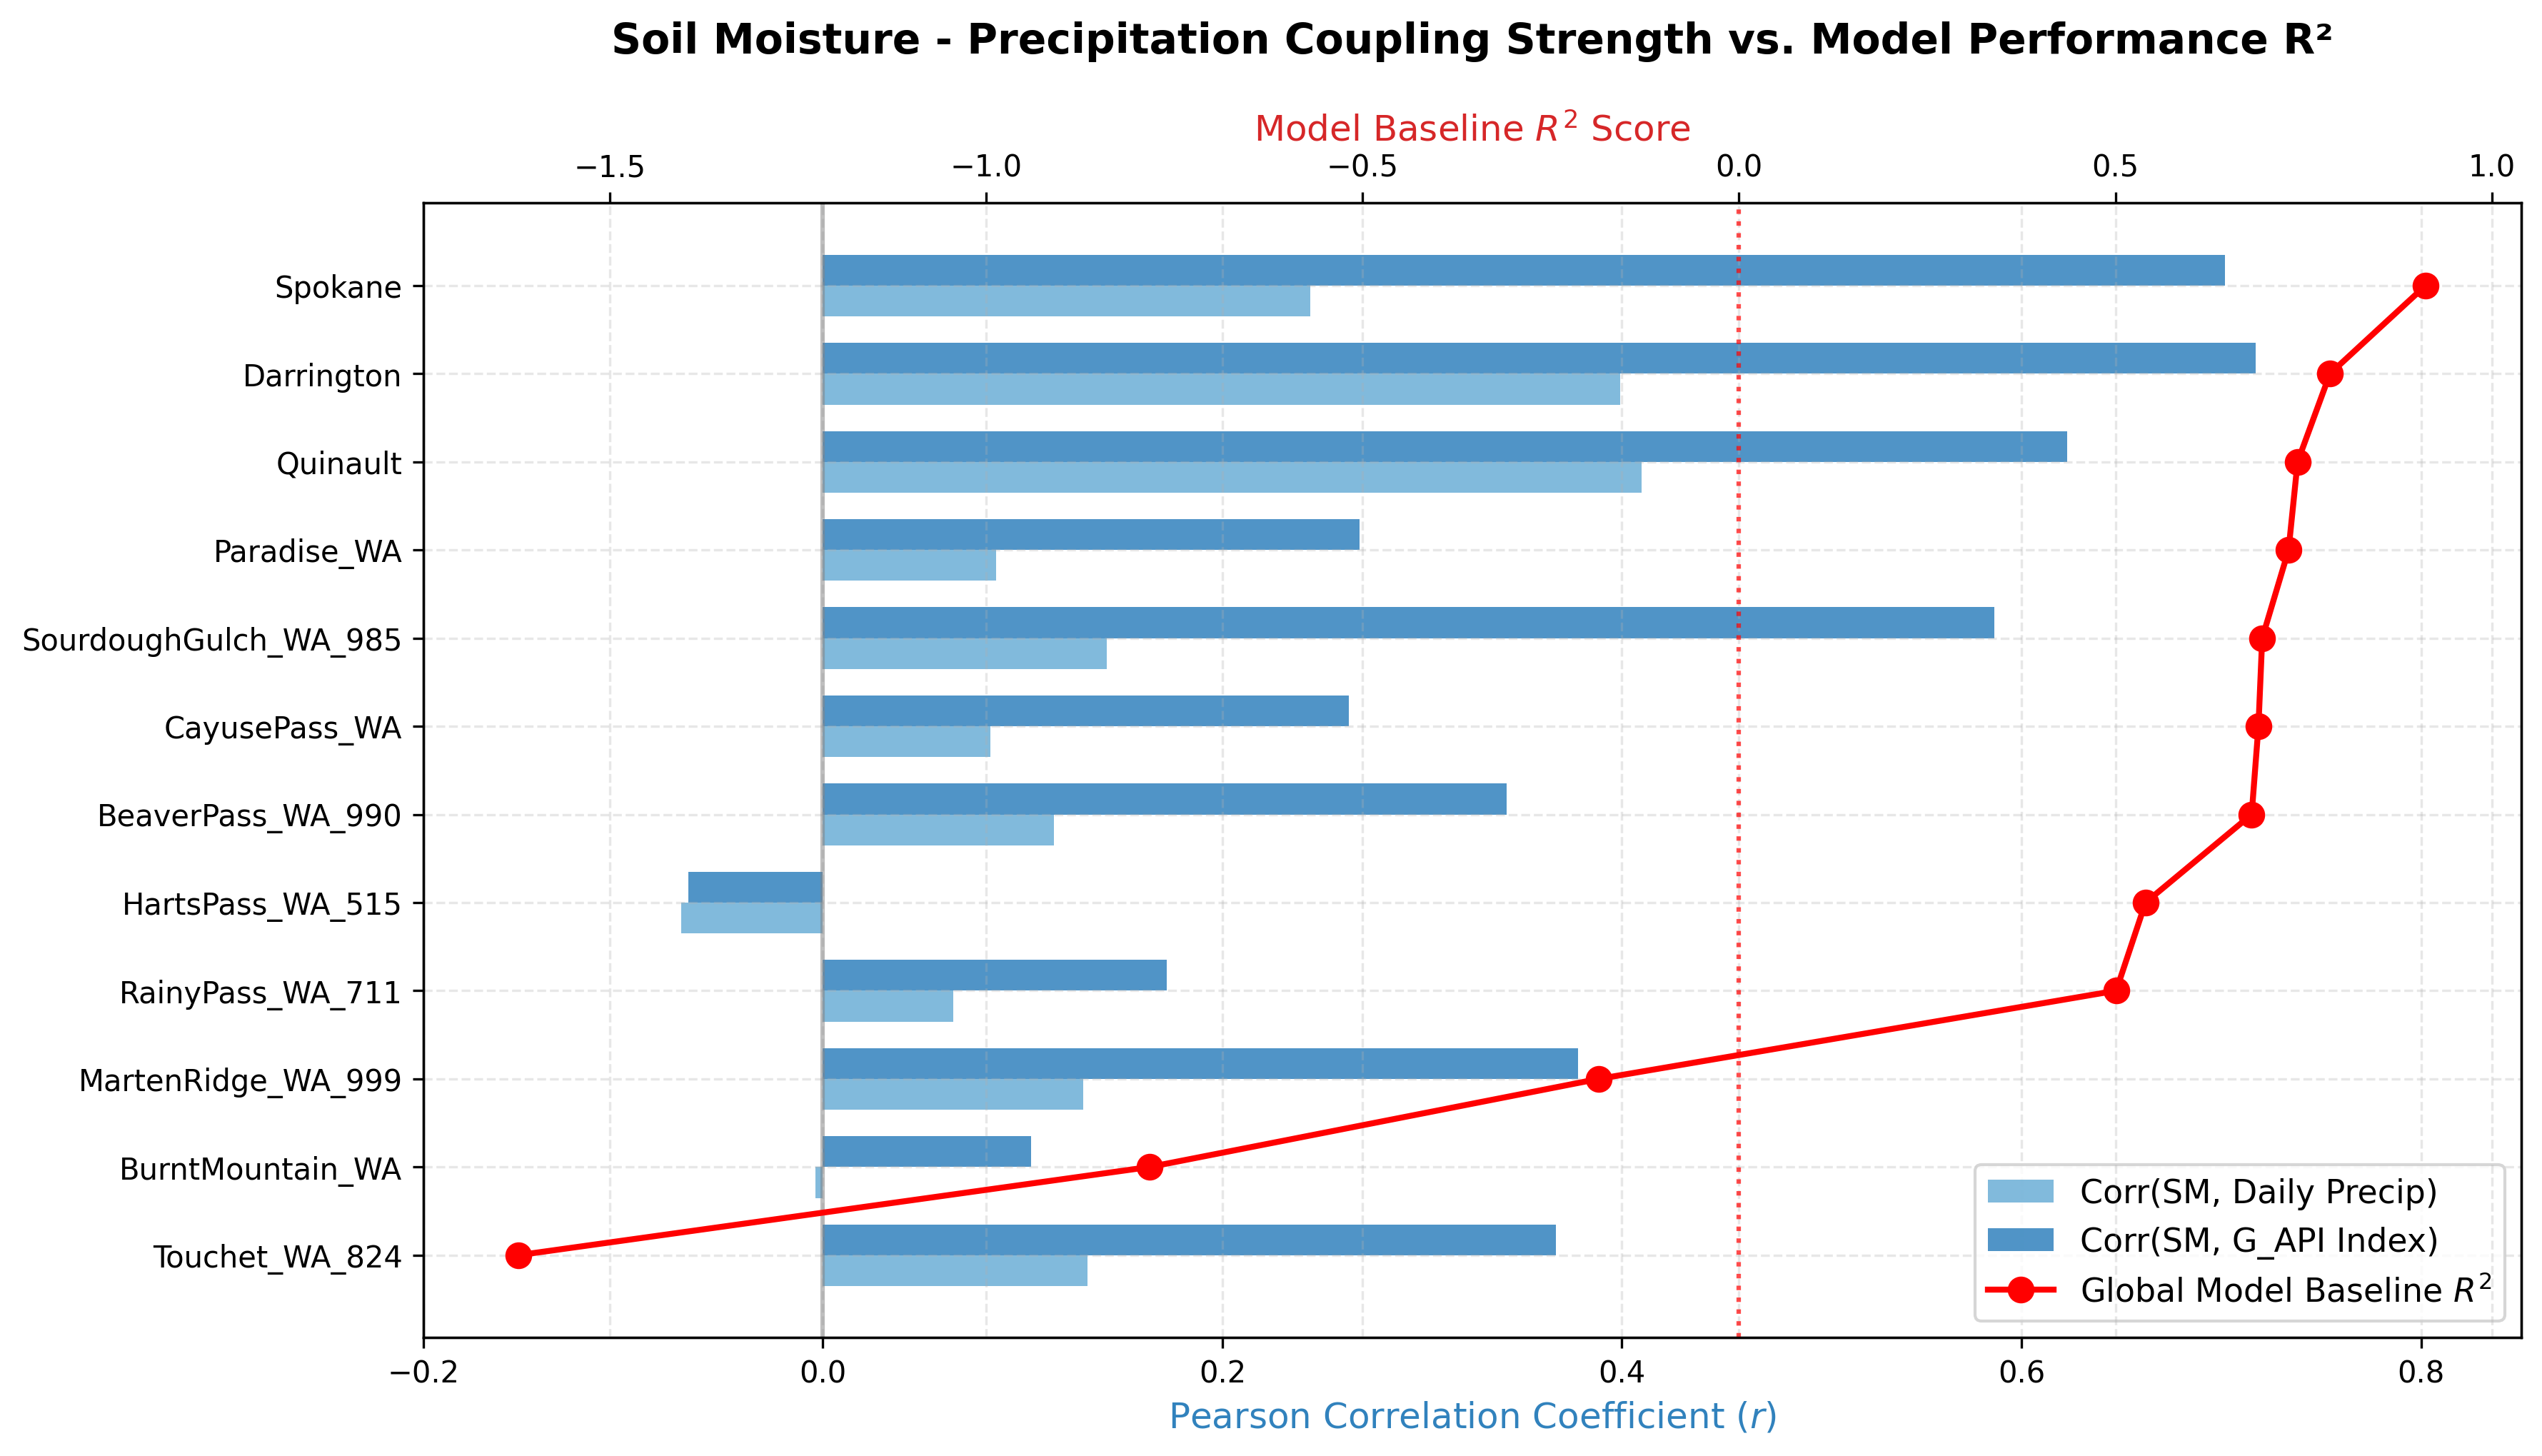

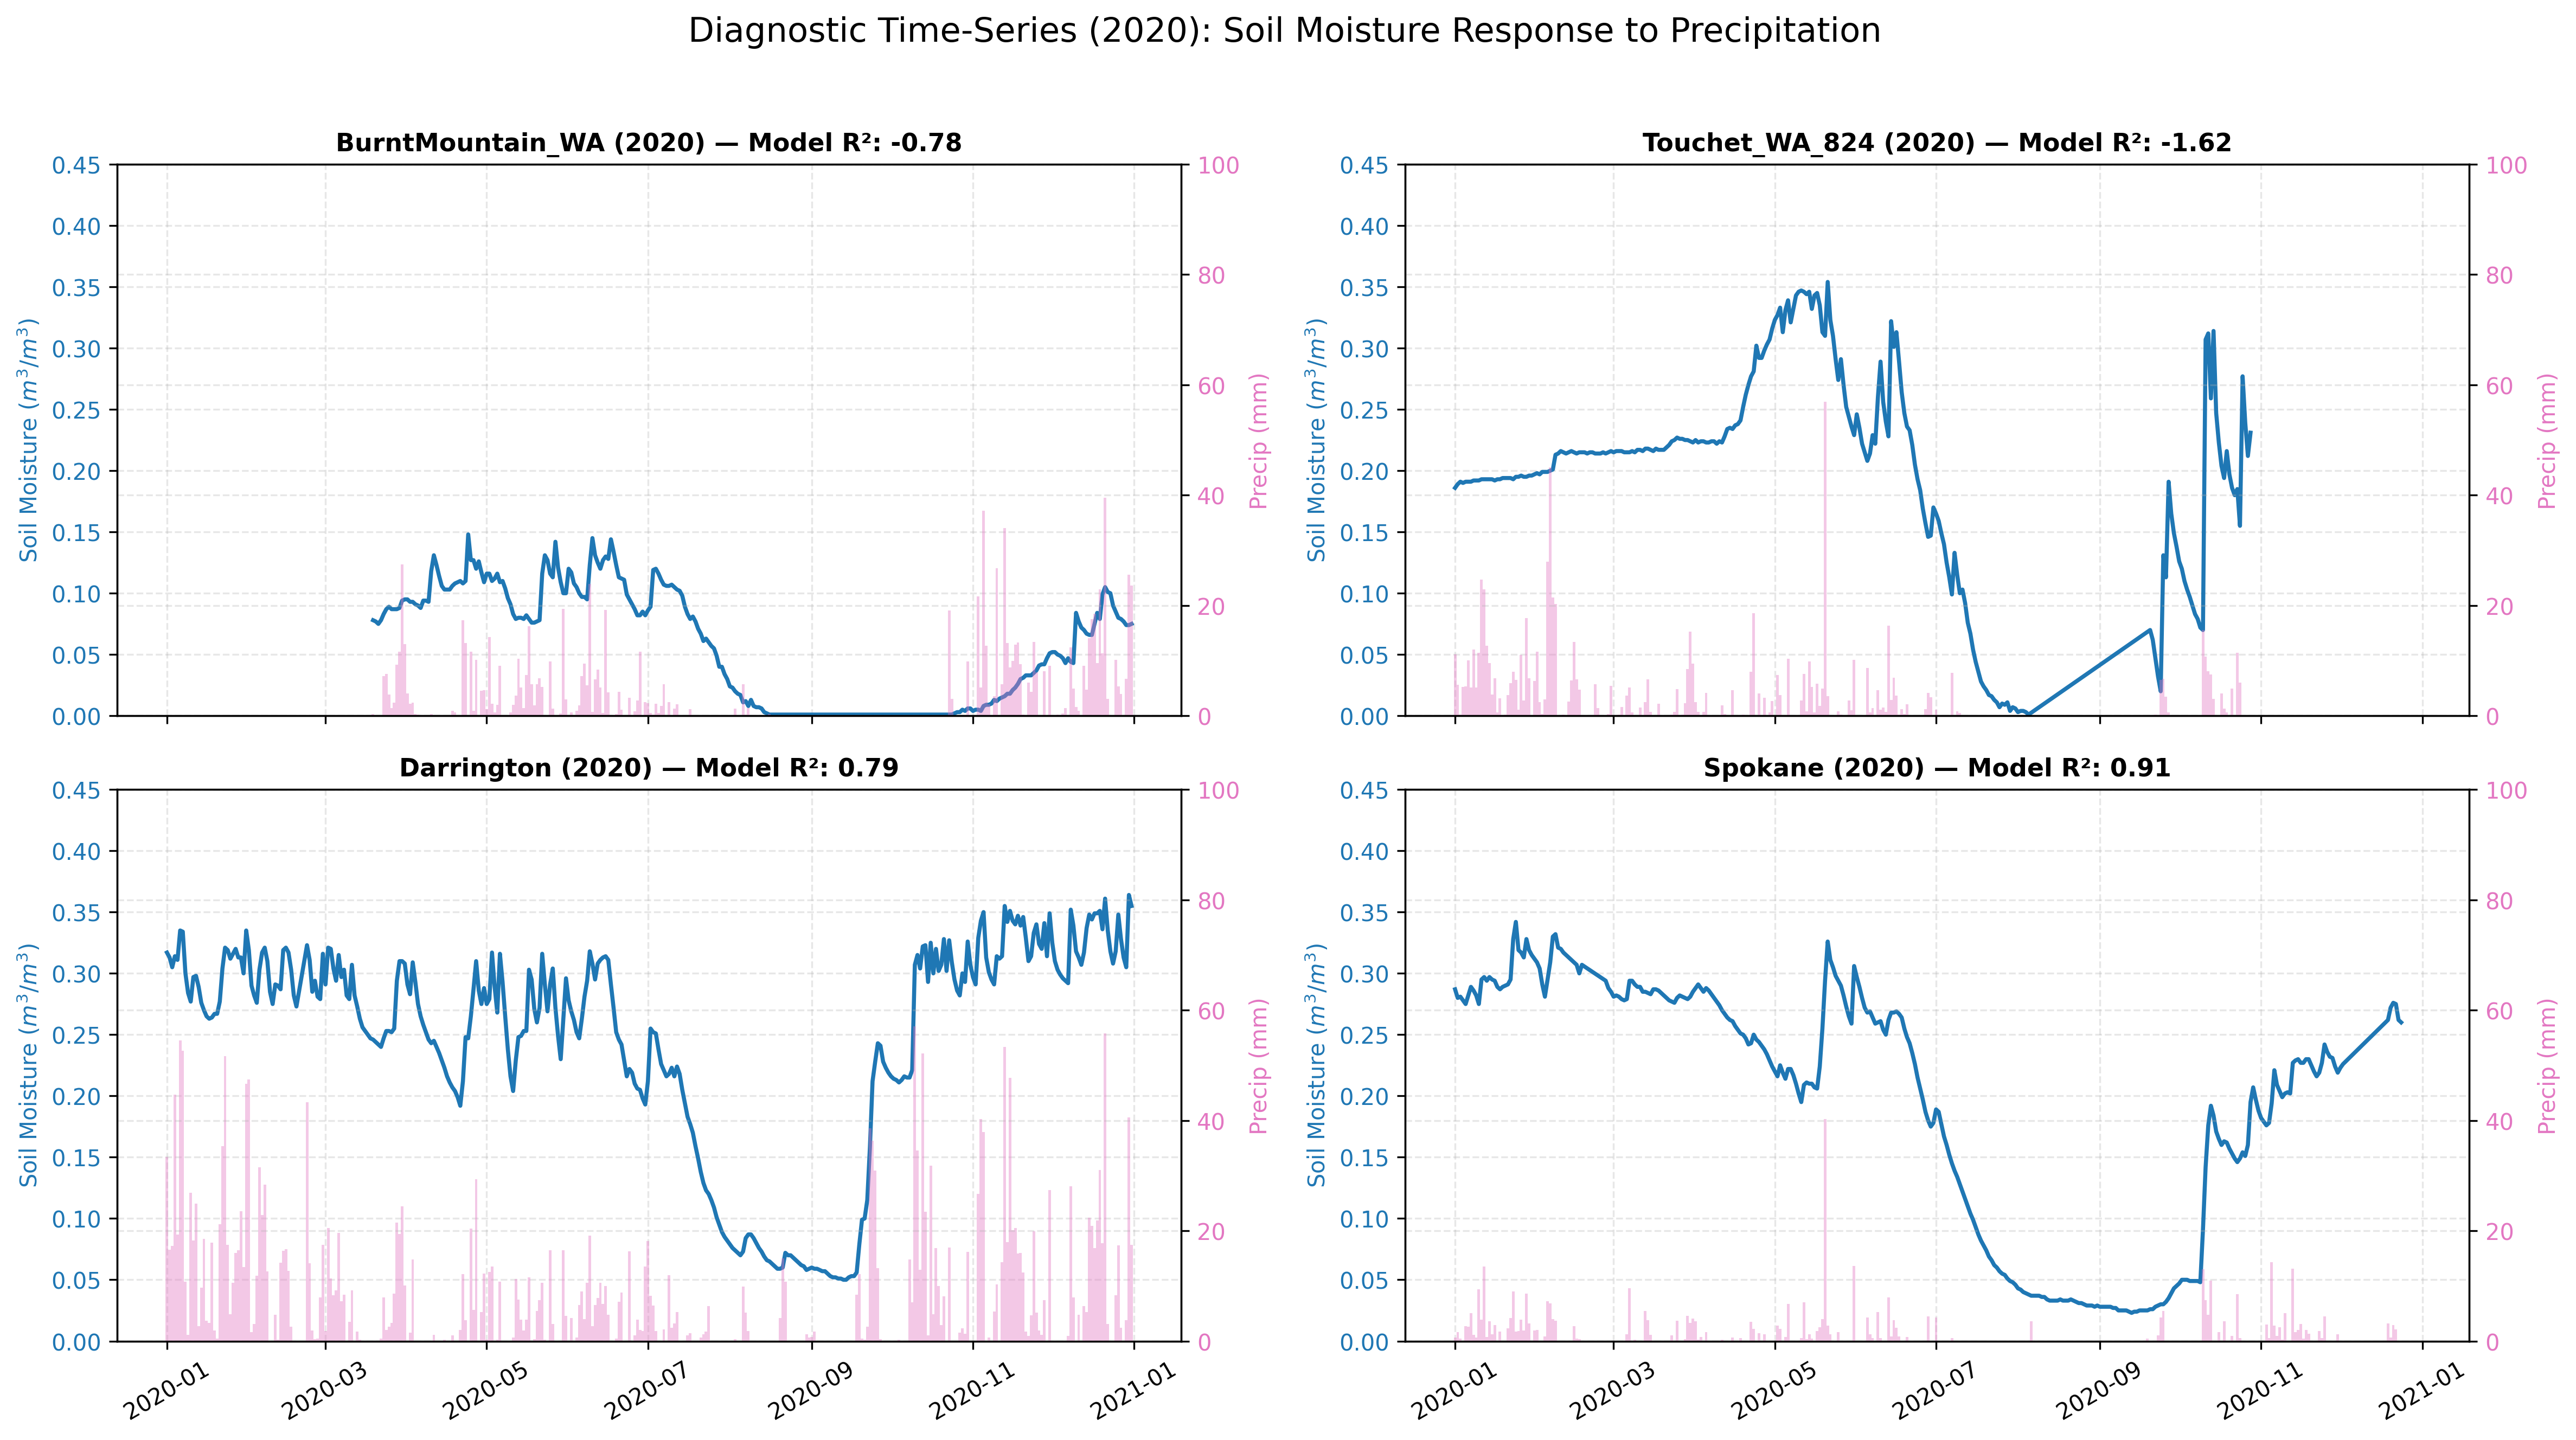

In [4]:
import analyze_sm_vs_precip
analyze_sm_vs_precip.main()

display(Image(os.path.join(nb_dir, 'sm_vs_precip_by_station.png')))
display(Image(os.path.join(nb_dir, 'sm_vs_g_api_by_station.png')))
display(Image(os.path.join(nb_dir, 'sm_precip_correlation_by_station.png')))
display(Image(os.path.join(nb_dir, 'sm_vs_precip_diagnostics_time.png')))